This model builds the SMILE model that predicts the WC of each water molecule for the Mg2+-water-Ne system. The original MD trajectory is contained in `Mg_ion_water_Ne.tar.gz`. The first two sections create the training and testing data containers and build the ACE descriptor matrices from them by reading the raw DFT data. These matrices are saved in the `.npy` files. One can also start directly from the third section `load the matrix`, which read the `.npy` files and build the SMILE model. In this way, the original DFT data and pyiron and pyace packages are not needed. 

In [1]:
from pyiron import Project
import numpy as np
%matplotlib inline
import matplotlib.pylab as plt
import pyace

/cmmc/ptmp/pyironhb/mambaforge/envs/pyiron_mpie_cmti_2026-03-02/lib/python3.12/site-packages/nglview/__init__.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
plt.rcParams.update(
    {'font.size': 24, 'legend.fontsize': 20, 
     'legend.handlelength': 0.5, 'lines.markersize':10,
     'axes.linewidth':2})

In [4]:
pr = Project('water_Ne')

# create data container

In [4]:
tc = pr.create.job.TrainingContainer("Ne_water_data_train_dipole")
phi_train = []
electrode_charge_train = []
for job_name in ['Mg_water_0', 'Mg_water_2',  'Mg_water_4']:
    job = pr.load(job_name)
    if job.status.finished:
        try:
            traj = job['output/generic/positions']
            dipole_moment = [i[-1,2] for i in job["output/generic/dft/scf_dipole_mom"]]
            charge = job['output/generic/dft/potentiostat_output']['electrode_charge']
            traj_length = np.shape(traj)[0]
            for i in range(traj_length):
                if i%10 == 0:
                    tc.include_job(job, iteration_step = i)
                    phi_train.append(dipole_moment[i])
                    electrode_charge_train.append(charge[i])
        except:
            continue

2025-03-25 09:13:17,948 - pyiron_log - INFO - Reconnecting to DB; connection was closed.
2025-03-25 09:13:18,013 - pyiron_log - DEBUG - sql_query: {'job': 'water_Ne_0', 'project': '/cmmc/ptmp/jyang/water_Ne/water_Ne/'}
/cmmc/ptmp/pyironhb/mambaforge/envs/pyiron_mpie_cmti_2025-03-24/lib/python3.11/site-packages/pyiron_snippets/resources.py:297: ResolverWarning: Found file '/cmmc/u/jyang/bin/pyiron-resources-cmmc/vasp/bin/run_vasp_6.4.0_python_gamma_mpi.sh', but skipping it because it is not executable!
  return dict(self.search(name=name))
/cmmc/ptmp/pyironhb/mambaforge/envs/pyiron_mpie_cmti_2025-03-24/lib/python3.11/site-packages/pyiron_snippets/resources.py:297: ResolverWarning: Found file '/cmmc/u/jyang/bin/pyiron-resources-cmmc/vasp/bin/run_vasp_6.4.0_python_mpi.sh', but skipping it because it is not executable!
  return dict(self.search(name=name))
/cmmc/ptmp/pyironhb/mambaforge/envs/pyiron_mpie_cmti_2025-03-24/lib/python3.11/site-packages/pyiron_snippets/resources.py:297: Resolver

In [5]:
tc.run()

2025-03-25 09:17:13,376 - pyiron_log - INFO - Reconnecting to DB; connection was closed.
2025-03-25 09:17:13,381 - pyiron_log - INFO - run job: Ne_water_data_train_dipole id: None, status: initialized
2025-03-25 09:17:14,339 - pyiron_log - INFO - run job: Ne_water_data_train_dipole id: 26919709, status: created


The job Ne_water_data_train_dipole was saved and received the ID: 26919709


2025-03-25 09:17:14,612 - pyiron_log - DEBUG - Not supported parameter used!
2025-03-25 09:17:15,312 - pyiron_log - DEBUG - Not supported parameter used!
2025-03-25 09:17:15,326 - pyiron_log - DEBUG - Not supported parameter used!
2025-03-25 09:17:15,349 - pyiron_log - DEBUG - Not supported parameter used!
2025-03-25 09:17:15,362 - pyiron_log - DEBUG - Not supported parameter used!
2025-03-25 09:17:15,373 - pyiron_log - DEBUG - Not supported parameter used!
2025-03-25 09:17:15,385 - pyiron_log - DEBUG - Not supported parameter used!
2025-03-25 09:17:15,399 - pyiron_log - DEBUG - Not supported parameter used!
2025-03-25 09:17:15,412 - pyiron_log - DEBUG - Not supported parameter used!
2025-03-25 09:17:15,423 - pyiron_log - DEBUG - Not supported parameter used!
2025-03-25 09:17:15,434 - pyiron_log - DEBUG - Not supported parameter used!
2025-03-25 09:17:15,446 - pyiron_log - DEBUG - Not supported parameter used!
2025-03-25 09:17:15,457 - pyiron_log - DEBUG - Not supported parameter used!

In [288]:
np.save("phi_test_verify.npy", phi_test)
np.save("electrode_charge_test_verify.npy", electrode_charge_test)


In [6]:
np.save("phi_train_verify.npy", phi_train)
np.save("electrode_charge_train_verify.npy", electrode_charge_train)


In [7]:
df = tc.to_pandas()

# create descriptor matrix

In [9]:
tc = pr.load('Mg_water_data_train_dipole_2')
df = tc.to_pandas()

2025-08-04 09:00:29,384 - pyiron_log - DEBUG - sql_query: {'job': 'Mg_water_data_train_dipole_2', 'project': '/cmmc/ptmp/jyang/water_Ne/water_Ne/'}
2025-08-04 09:00:29,538 - pyiron_log - INFO - Reconnecting to DB; connection was closed.


In [205]:
# H Mg Ne O
def make_ace(**kwargs):
    calc = pyace.PyACECalculator(
            '../Mg_200.yaml'
    )
    return calc

In [206]:
def get_descr(ace, structure):
    #del structure.calc
    structure.calc = ace
    structure.get_potential_energy()
    return np.array(structure.calc.ace.projections)

In [207]:
struct = df['atoms'][0]

In [208]:
index_O = struct.select_index('O')
index_H = struct.select_index('H')
index_Mg = struct.select_index('Mg')

In [209]:
ace = make_ace()
d_ace = get_descr(ace, struct)

2025-06-10 15:55:28,776 - pyiron_log - DEBUG - Not supported parameter used!


In [20]:
np.shape(d_ace)

(216, 200)

In [210]:
tc = pr.load('Mg_water_data_train_dipole')
df = tc.to_pandas()

2025-06-10 15:55:31,635 - pyiron_log - DEBUG - sql_query: {'job': 'Mg_water_data_train_dipole', 'project': '/cmmc/ptmp/jyang/water_Ne/water_Ne/'}


In [211]:
cos_test_list = []
descriptor_list = []
core_center_list = []
z_list = []
vec_list = []
n_step = len(df)
for i in range(n_step):
    struct = df['atoms'][i]
    d_ace = get_descr(ace, struct)
    nn = struct.get_neighbors(num_neighbors= 2)
    
    for iO in index_O:
        ddd = np.insert(d_ace[iO], 0, 1) 
        vec1 = nn.vecs[iO][0]
        vec2 = nn.vecs[iO][1]
        i_H1 = nn.indices[iO][0]
        i_H2 = nn.indices[iO][1]
        ddd_H1 = np.insert(d_ace[i_H1], 0, 1) 
        ddd_H2 = np.insert(d_ace[i_H2], 0, 1) 
        z_norm = np.array([0, 0, 1])
        vec = (vec1 + vec2)/2
        cos_theta = np.dot(vec, z_norm)/np.linalg.norm(vec)
        cos_test_list.append(cos_theta)
        descriptor_list.append(np.concatenate((ddd, ddd_H1, ddd_H2)))
        core_center = (struct.positions[iO, 2]*6 + struct.positions[i_H1,2] + struct.positions[i_H2, 2])/8
        core_center_list.append(core_center)
        z_list.append([struct.positions[iO, 2], struct.positions[i_H1,2], struct.positions[i_H2,2]])
        vec_list.append([vec1, vec2])
cos_test_list = np.array(cos_test_list)
descriptor_list = np.array(descriptor_list)
vec_list = np.array(vec_list) 

2025-06-10 15:55:38,225 - pyiron_log - DEBUG - Not supported parameter used!
2025-06-10 15:55:38,236 - pyiron_log - DEBUG - Not supported parameter used!
2025-06-10 15:55:38,273 - pyiron_log - DEBUG - Not supported parameter used!
2025-06-10 15:55:38,281 - pyiron_log - DEBUG - Not supported parameter used!
2025-06-10 15:55:38,315 - pyiron_log - DEBUG - Not supported parameter used!
2025-06-10 15:55:38,323 - pyiron_log - DEBUG - Not supported parameter used!
2025-06-10 15:55:38,357 - pyiron_log - DEBUG - Not supported parameter used!
2025-06-10 15:55:38,365 - pyiron_log - DEBUG - Not supported parameter used!
2025-06-10 15:55:38,398 - pyiron_log - DEBUG - Not supported parameter used!
2025-06-10 15:55:38,407 - pyiron_log - DEBUG - Not supported parameter used!
2025-06-10 15:55:38,440 - pyiron_log - DEBUG - Not supported parameter used!
2025-06-10 15:55:38,448 - pyiron_log - DEBUG - Not supported parameter used!
2025-06-10 15:55:38,481 - pyiron_log - DEBUG - Not supported parameter used!

In [212]:
H_pos_list = []
O_pos_list = []
Mg_pos_list = []
n_step = len(df)
for i in range(n_step):
    struct = df['atoms'][i]
    O_pos_list.append(struct.positions[index_O])
    H_pos_list.append(struct.positions[index_H])
    Mg_pos_list.append(struct.positions[index_Mg])
H_pos_list = np.array(H_pos_list)
O_pos_list = np.array(O_pos_list)
Mg_pos_list = np.array(Mg_pos_list)

In [213]:
np.save('H_pos_list_shift.npy', H_pos_list)
np.save('O_pos_list_shift.npy', O_pos_list)
np.save('Mg_pos_list_shift.npy', Mg_pos_list)

In [215]:
np.save('descriptor_list_shift_func200.npy', descriptor_list)

In [116]:
np.save('descriptor_list_verify_func200.npy', descriptor_list)

In [216]:
vec_3d_list = []
vec_OH1_list = []
vec_OH2_list = []
vec_norm_list = []
for i in range(len(vec_list)):
    c = np.cross(vec_list[i,0], vec_list[i, 1])
    c = c/np.linalg.norm(c)
    b1 = vec_list[i,0]/np.linalg.norm(vec_list[i,0])
    b2 = vec_list[i,1]/np.linalg.norm(vec_list[i,1])
    vec_3d_list.append([b1, b2, c])
    vec_OH1_list.append(b1)
    vec_OH2_list.append(b2)
    vec_norm_list.append(c)
vec_3d_list = np.array(vec_3d_list)
vec_OH1_list = np.array(vec_OH1_list)
vec_OH2_list = np.array(vec_OH2_list)
vec_norm_list = np.array(vec_norm_list)

In [217]:
np.save('vec_OH1_list.npy', vec_OH1_list)
np.save('vec_OH2_list.npy', vec_OH2_list)
np.save('vec_norm_list.npy', vec_norm_list)

In [218]:
def decompose_vector(a, b1, b2):
    """
    Decomposes a vector 'a' into components along 'b1', 'b2' (plane basis) and 'c' (normal).
    
    Parameters:
    a  : (3,) array-like, the vector to be decomposed
    b1 : (3,) array-like, first basis vector of the plane
    b2 : (3,) array-like, second basis vector of the plane
    c  : (3,) array-like, normal vector to the plane

    Returns:
    (x, y, z): Coefficients such that a = x * b1 + y * b2 + z * c
    """
    c = np.cross(b1, b2)
    c = c/np.linalg.norm(c)

    b1_norm = b1/np.linalg.norm(b1)
    b2_norm = b2/np.linalg.norm(b2)
    # Construct the basis matrix B with b1, b2, and normal c as columns
    B = np.column_stack((b1_norm, b2_norm, c))  # Shape (3,3)

    # Solve for x, y, z
    xyz = np.linalg.solve(B, a)  # Solves B * [x, y, z] = a
    
    return xyz

In [222]:
np.save('core_center_list_shift.npy', core_center_list)

In [219]:
np.save('cos_test_list_shift.npy', cos_test_list) 
np.save('descriptor_list_shift.npy', descriptor_list)
np.save('vec_list_shift.npy', vec_list) 
np.save('vec_3d_list_shift.npy', vec_3d_list) 
np.save('z_list_shift.npy', z_list)

In [ ]:
tc = pr.load("Mg_water_data_train_dipole")
df = tc.to_pandas()

# load the matrix

In [3]:
cos_test_list = np.load('cos_test_list_shift.npy')
descriptor_list = np.load('descriptor_list_shift.npy')
vec_list = np.load('vec_list_shift.npy')
vec_3d_list = np.load('vec_3d_list_shift.npy')
z_list = np.load('z_list_shift.npy')
core_center_list = np.load('core_center_list_shift.npy')
vec_3d_list_full = vec_3d_list.reshape([-1, 63, 3, 3])[:, :, :, 2]

In [4]:
vec_3d_list_test = np.load('vec_3d_list_shift_test.npy') 
vec_3d_list_full_test = vec_3d_list_test.reshape([-1, 63, 3, 3])[:, :, :, 2]

In [5]:
phi_train = np.load('phi_train.npy')

In [6]:
phi_test = np.load('phi_test_shift.npy')

In [7]:
H_pos_list = np.load('H_pos_list_shift.npy')
O_pos_list = np.load('O_pos_list_shift.npy')

Mg_pos_list = np.load('Mg_pos_list_shift.npy')

In [8]:
H_pos_test_list = np.load('H_pos_list_shift_test.npy')
O_pos_test_list = np.load('O_pos_list_shift_test.npy')
Mg_pos_test_list = np.load('Mg_pos_list_shift_test.npy')

In [11]:
z_Mg_list = np.load('z_Mg_list.npy')

In [12]:
vec_OH1_list = np.load('vec_OH1_list.npy')
vec_OH2_list = np.load('vec_OH2_list.npy')
vec_norm_list = np.load('vec_norm_list.npy')

# fit to global dipole

In [13]:
shape  = np.shape(descriptor_list)

In [14]:
cos_theta_list = np.zeros((shape[0], 3))
cos_theta_list[:, 0] = vec_OH1_list[:, 2]
cos_theta_list[:, 1] = vec_OH2_list[:, 2]
cos_theta_list[:, 2] = vec_norm_list[:, 2]

In [15]:
mat = descriptor_list.reshape([-1, 63, shape[1]])

In [16]:
cos_theta_list_full = cos_theta_list.reshape([-1, 63, 3])
A = np.einsum('ijk, ijl -> ikl', mat, cos_theta_list_full)
A_reshaped = A.reshape(1200, -1)

In [17]:
pos_Ne = 24.656269320469203
dipole_Mg_Ne = -2*Mg_pos_list[:, 0, 2] + 12*(2/24)*pos_Ne
dipole_Mg_Ne_test = -2*Mg_pos_test_list[:, 0, 2] + 12*(2/24)*pos_Ne

In [18]:
m, n = A_reshaped.shape  # Get matrix dimensions
I = np.eye(n)   # Identity matrix of size n x n
lambda_reg = 10
# Compute regularized solution: x = (A^T A + lambda*I)^-1 A^T b
mat_inv = np.linalg.inv(A_reshaped.T @ A_reshaped + lambda_reg * I) @ A_reshaped.T
alpha = 2.3
d_matrix = mat_inv@((phi_train*alpha-dipole_Mg_Ne))
phi_fit = A_reshaped@d_matrix

In [19]:
d_matrix = d_matrix.reshape(-1, 3)
OH1_predict = mat@d_matrix[:, 0]
OH2_predict = mat@d_matrix[:, 1]
norm_predict = mat@d_matrix[:, 2]

In [20]:
OH1_contrib_z = OH1_predict*vec_OH1_list[:, 2].reshape(1200, -1)
OH2_contrib_z = OH2_predict*vec_OH2_list[:, 2].reshape(1200, -1)
norm_contrib_z = norm_predict*vec_norm_list[:, 2].reshape(1200, -1)

OH1_contrib_x = OH1_predict*vec_OH1_list[:, 0].reshape(1200, -1)
OH2_contrib_x = OH2_predict*vec_OH2_list[:, 0].reshape(1200, -1)
norm_contrib_x = norm_predict*vec_norm_list[:, 0].reshape(1200, -1)

OH1_contrib_y = OH1_predict*vec_OH1_list[:, 1].reshape(1200, -1)
OH2_contrib_y = OH2_predict*vec_OH2_list[:, 1].reshape(1200, -1)
norm_contrib_y = norm_predict*vec_norm_list[:, 1].reshape(1200, -1)

In [21]:
shape = np.shape(OH1_contrib_z)
dipole_predict = np.zeros((shape[0], shape[1], 3))
dipole_predict[:, :, 2] = OH1_contrib_z + OH2_contrib_z + norm_contrib_z
dipole_predict[:, :, 0] = OH1_contrib_x + OH2_contrib_x + norm_contrib_x
dipole_predict[:, :, 1] = OH1_contrib_y + OH2_contrib_y + norm_contrib_y

In [22]:
dipole_magnitude = np.linalg.norm(dipole_predict, axis = 2)

In [23]:
np.mean(dipole_magnitude)

np.float64(0.6209007525465435)

In [24]:
phi_fit_2 = np.sum(dipole_predict[:, :, 2], axis = 1)

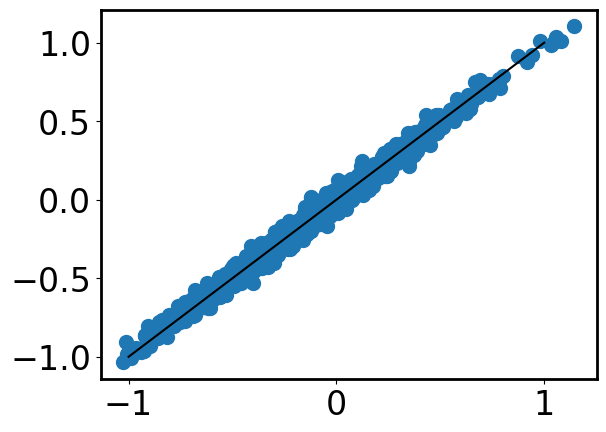

In [25]:
plt.scatter(phi_train, (phi_fit+dipole_Mg_Ne)/alpha)
plt.plot([-1, 1], [-1, 1], color = 'Black')

# effect of n_descriptor, alpha and lambda

In [27]:
def fit_water(alpha, lambda_reg, descriptor_list, vec_3d_list_full, phi_train, dipole_Mg_Ne, return_individual_dipole = False):
    n1, n2 = np.shape(descriptor_list)
    cos_theta_list = np.zeros((n1, 3))
    cos_theta_list[:, 0] = vec_3d_list_full[:, :, 0].reshape(-1)
    cos_theta_list[:, 1] = vec_3d_list_full[:, :, 1].reshape(-1)
    cos_theta_list[:, 2] = vec_3d_list_full[:, :, 2].reshape(-1)
    mat = descriptor_list.reshape([-1, 63, n2])
    shape = np.shape(mat)
    cos_theta_list_full = cos_theta_list.reshape([-1, 63, 3])
    A = np.einsum('ijk, ijl -> ikl', mat, cos_theta_list_full)
    A_reshaped = A.reshape(-1, n2*3)
    m, n = A_reshaped.shape  # Get matrix dimensions
    I = np.eye(n)   # Identity matrix of size n x n
    # Compute regularized solution: x = (A^T A + lambda*I)^-1 A^T b
    mat_inv = np.linalg.inv(A_reshaped.T @ A_reshaped + lambda_reg * I) @ A_reshaped.T
    d_matrix = mat_inv@((phi_train*alpha - dipole_Mg_Ne))
    #d_matrix = mat_inv@(alpha*(phi_train - dipole_Mg_Ne))
    phi_fit = A_reshaped@d_matrix
    phi_fit = phi_fit.reshape(-1)
    d_matrix = d_matrix.reshape(n2, 3)
    OH1_predict = mat@d_matrix[:, 0]
    OH2_predict = mat@d_matrix[:, 1]
    norm_predict = mat@d_matrix[:, 2]
    
    OH1_contrib_z = OH1_predict*vec_3d_list[:, 0, 2].reshape(shape[0], -1)
    OH2_contrib_z = OH2_predict*vec_3d_list[:, 1, 2].reshape(shape[0], -1)
    norm_contrib_z = norm_predict*vec_3d_list[:, 2, 2].reshape(shape[0], -1)
    
    OH1_contrib_x = OH1_predict*vec_3d_list[:, 0, 0].reshape(shape[0], -1)
    OH2_contrib_x = OH2_predict*vec_3d_list[:, 1, 0].reshape(shape[0], -1)
    norm_contrib_x = norm_predict*vec_3d_list[:, 2, 0].reshape(shape[0], -1)
    
    OH1_contrib_y = OH1_predict*vec_3d_list[:, 0, 1].reshape(shape[0], -1)
    OH2_contrib_y = OH2_predict*vec_3d_list[:, 1, 1].reshape(shape[0], -1)
    norm_contrib_y = norm_predict*vec_3d_list[:, 2, 1].reshape(shape[0], -1)

    shape = np.shape(OH1_contrib_z)
    dipole_predict = np.zeros((shape[0], shape[1], 3))
    dipole_predict[:, :, 2] = OH1_contrib_z + OH2_contrib_z + norm_contrib_z
    dipole_predict[:, :, 0] = OH1_contrib_x + OH2_contrib_x + norm_contrib_x
    dipole_predict[:, :, 1] = OH1_contrib_y + OH2_contrib_y + norm_contrib_y
    
    dipole_magnitude = np.linalg.norm(dipole_predict, axis = 2)
    #error = np.sqrt(np.mean((phi_train - (phi_fit/alpha + dipole_Mg_Ne))**2))
    error = np.sqrt(np.mean((phi_train - (phi_fit + dipole_Mg_Ne)/alpha)**2))
    if return_individual_dipole:
        return error, np.mean(dipole_magnitude), d_matrix, phi_fit, dipole_predict
    else:
        return error, np.mean(dipole_magnitude), d_matrix, phi_fit

In [28]:
def get_test_error(d_matrix, alpha, descriptor_list, vec_3d_list_full, vec_3d_list, phi_test, dipole_Mg_Ne):
    n1, n2 = np.shape(descriptor_list)
    cos_theta_list = np.zeros((n1, 3))
    cos_theta_list[:, 0] = vec_3d_list_full[:, :, 0].reshape(-1)
    cos_theta_list[:, 1] = vec_3d_list_full[:, :, 1].reshape(-1)
    cos_theta_list[:, 2] = vec_3d_list_full[:, :, 2].reshape(-1)
    mat = descriptor_list.reshape([-1, 63, n2])
    shape = np.shape(mat)
    cos_theta_list_full = cos_theta_list.reshape([-1, 63, 3])
    A = np.einsum('ijk, ijl -> ikl', mat, cos_theta_list_full)
    A_reshaped = A.reshape(-1, n2*3)
    d_matrix = d_matrix.reshape(n2*3, -1)
    A_reshaped = A.reshape(-1, 3*n2)
    phi_fit = A_reshaped@d_matrix
    phi_fit = phi_fit.reshape(-1)
    d_matrix = d_matrix.reshape(n2, 3)
    OH1_predict = mat@d_matrix[:, 0]
    OH2_predict = mat@d_matrix[:, 1]
    norm_predict = mat@d_matrix[:, 2]
    
    OH1_contrib_z = OH1_predict*vec_3d_list[:, 0, 2].reshape(shape[0], -1)
    OH2_contrib_z = OH2_predict*vec_3d_list[:, 1, 2].reshape(shape[0], -1)
    norm_contrib_z = norm_predict*vec_3d_list[:, 2, 2].reshape(shape[0], -1)
    
    OH1_contrib_x = OH1_predict*vec_3d_list[:, 0, 0].reshape(shape[0], -1)
    OH2_contrib_x = OH2_predict*vec_3d_list[:, 1, 0].reshape(shape[0], -1)
    norm_contrib_x = norm_predict*vec_3d_list[:, 2, 0].reshape(shape[0], -1)
    
    OH1_contrib_y = OH1_predict*vec_3d_list[:, 0, 1].reshape(shape[0], -1)
    OH2_contrib_y = OH2_predict*vec_3d_list[:, 1, 1].reshape(shape[0], -1)
    norm_contrib_y = norm_predict*vec_3d_list[:, 2, 1].reshape(shape[0], -1)
    
    shape = np.shape(OH1_contrib_z)
    dipole_predict = np.zeros((shape[0], shape[1], 3))
    dipole_predict[:, :, 2] = OH1_contrib_z + OH2_contrib_z + norm_contrib_z
    dipole_predict[:, :, 0] = OH1_contrib_x + OH2_contrib_x + norm_contrib_x
    dipole_predict[:, :, 1] = OH1_contrib_y + OH2_contrib_y + norm_contrib_y
    
    dipole_magnitude = np.linalg.norm(dipole_predict, axis = 2)
    #error = np.sqrt(np.mean((phi_test - (phi_fit/alpha + dipole_Mg_Ne))**2))
    
    error = np.sqrt(np.mean((phi_test - (phi_fit + dipole_Mg_Ne)/alpha)**2))
    return error, np.mean(dipole_magnitude), phi_fit
    
    

In [29]:
alpha = 2.2
lambda_reg = 100
descriptor_list = np.load('descriptor_list_shift_train_func200.npy')
descriptor_list_test = np.load('descriptor_list_shift_test_func200.npy')
error, ave_dipole, d_matrix, phi_fit = fit_water(alpha, lambda_reg, descriptor_list, vec_3d_list_full, phi_train, dipole_Mg_Ne)
error_test, ave_dipole_test, phi_fit_test = get_test_error(d_matrix, alpha, descriptor_list_test, vec_3d_list_full_test, vec_3d_list_test, phi_test, dipole_Mg_Ne_test)

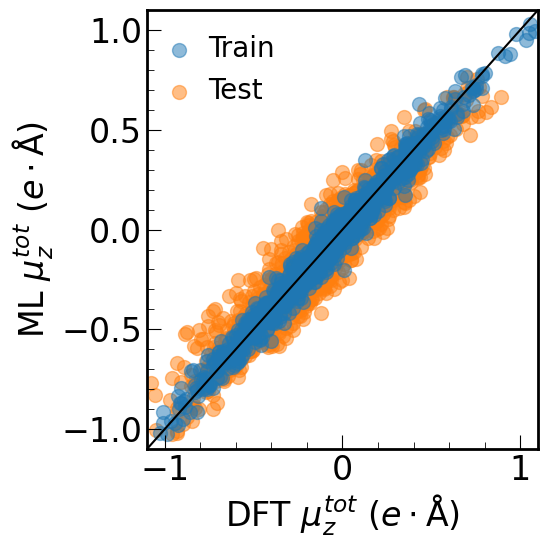

In [32]:
fig, ax = plt.subplots(figsize = (6,6))

plt.scatter(phi_test, (phi_fit_test+dipole_Mg_Ne_test)/alpha, alpha =0.5, label = 'Test', color = 'C1')

plt.scatter(phi_train, (phi_fit+dipole_Mg_Ne)/alpha, alpha =0.5, label = 'Train', color = 'C0')

plt.plot([-1.1, 1.1], [-1.1, 1.1], color = 'Black')
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[::-1], labels[::-1], frameon = False)
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)

ax.tick_params(axis='x', which='major', direction='in', length=10)
ax.tick_params(axis='x', which='minor', direction='in', length=5)
ax.tick_params(axis='y', which='major', direction='in', length=10)
ax.tick_params(axis='y', which='minor', direction='in', length=5)
ax.minorticks_on()
plt.xlabel(r'DFT $\mu_z^{tot}\ (e\cdot\mathrm{\AA})$')
plt.ylabel(r'ML $\mu_z^{tot}\ (e\cdot\mathrm{\AA})$')
plt.tight_layout()

plt.savefig('learn_global_correlation.png', dpi = 300)

## lambda

In [35]:
#alpha = 1.78
alpha = 2.2
error_list = []
ave_dipole_list = []

error_test_list = []
ave_dipole_test_list = []

descriptor_list = np.load('descriptor_list_shift.npy')
descriptor_list_test = np.load('descriptor_list_shift_test_func200.npy')

lambda_reg_list = [0.1, 1, 10, 100, 1000, 1e4]
for lambda_reg in lambda_reg_list:
    error, ave_dipole, d_matrix, phi_fit = fit_water(alpha, lambda_reg, descriptor_list, vec_3d_list_full, phi_train, dipole_Mg_Ne)
    ave_dipole_list.append(ave_dipole)
    error_list.append(error)
    error_test, ave_dipole_test, phi_fit_test = get_test_error(d_matrix, alpha, descriptor_list_test, vec_3d_list_full_test, vec_3d_list_test, phi_test, dipole_Mg_Ne_test)
    error_test_list.append(error_test)
    ave_dipole_test_list.append(ave_dipole_test)

Text(0, 0.5, 'ave dipole')

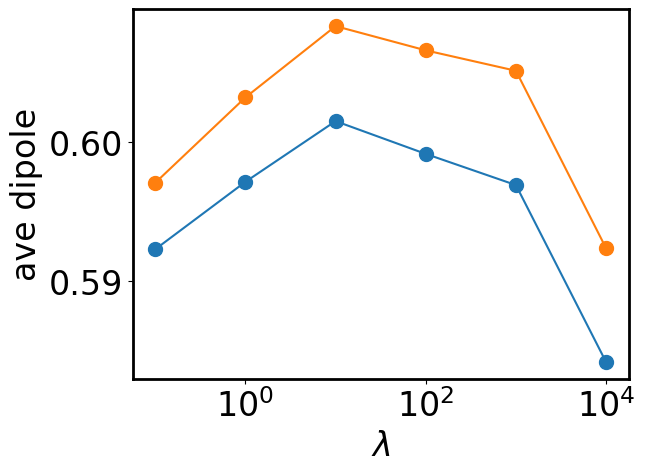

In [36]:
plt.plot(lambda_reg_list, ave_dipole_list, '-o')
plt.plot(lambda_reg_list, ave_dipole_test_list, '-o')
plt.xlabel('$\lambda$')
plt.xscale('log')
plt.ylabel('ave dipole')

Text(0, 0.5, 'error')

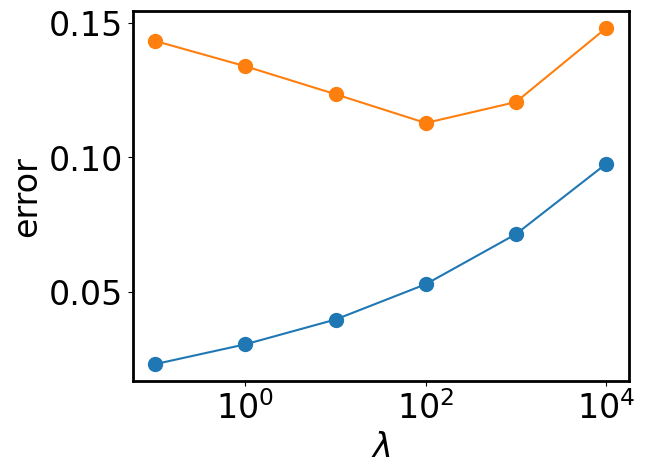

In [37]:
plt.plot(lambda_reg_list, error_list, '-o')
plt.plot(lambda_reg_list, error_test_list, '-o')
plt.xlabel('$\lambda$')
plt.xscale('log')
plt.ylabel('error')

## alpha

In [38]:
vec_3d_list_full = vec_3d_list.reshape([-1, 63, 3, 3])[:, :, :, 2]

In [446]:
alpha_list = np.linspace(1, 2.4, 10)
ave_dipole_list = []
error_list = []
error_test_list = []
ave_dipole_test_list = []
lambda_reg = 100

descriptor_list = np.load('descriptor_list_shift.npy')
#descriptor_list_test = np.load('descriptor_list_verify_test.npy')


for alpha in alpha_list:
    error, ave_dipole, d_matrix, phi_fit = fit_water(alpha, lambda_reg, descriptor_list, vec_3d_list_full, phi_train, dipole_Mg_Ne)
    ave_dipole_list.append(ave_dipole)
    error_list.append(error)
    error_test, ave_dipole_test, phi_fit = get_test_error(d_matrix, alpha, descriptor_list_test, vec_3d_list_full_test, vec_3d_list_test, phi_test, dipole_Mg_Ne_test)
    error_test_list.append(error_test)
    ave_dipole_test_list.append(ave_dipole_test)

/tmp/ipykernel_11654/636380559.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon = False)


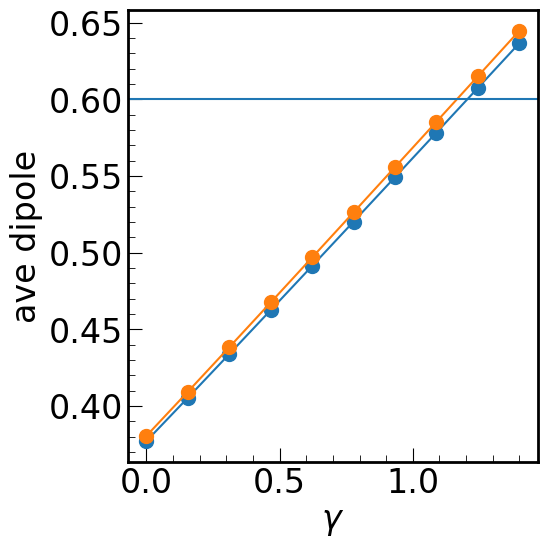

In [40]:
fig, ax = plt.subplots(figsize = (6,6))


plt.plot(np.array(alpha_list)-1, ave_dipole_list, '-o')
plt.plot(np.array(alpha_list)-1, ave_dipole_test_list, '-o')
plt.axhline(0.6)
plt.xlabel(r'$\gamma$')
#plt.xscale('log')
plt.ylabel('ave dipole')

plt.legend(frameon = False)
ax.tick_params(axis='x', which='major', direction='in', length=10)
ax.tick_params(axis='x', which='minor', direction='in', length=5)
ax.tick_params(axis='y', which='major', direction='in', length=10)
ax.tick_params(axis='y', which='minor', direction='in', length=5)
ax.minorticks_on()

plt.tight_layout()
plt.savefig('dipole_lambda_Mg.png', dpi = 300)

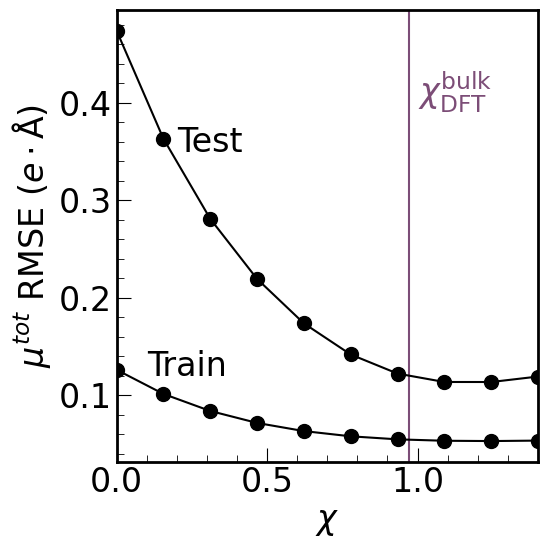

In [461]:
fig, ax = plt.subplots(figsize = (6,6))


plt.axvline(0.97, color = '#7C4D77')
plt.text(1, 0.4, '$\chi_{\mathrm{DFT}}^{\mathrm{bulk}}$', color = '#7C4D77')

plt.plot(np.array(alpha_list)-1, error_list, '-o', label = 'Train', color = 'Black')
plt.plot(np.array(alpha_list)-1, error_test_list, '-o', label = 'Test', color = 'Black')
plt.xlabel(r'$\chi$')
#plt.xscale('log')
plt.ylabel(r'$\mu^{tot}$ RMSE ($e\cdot\mathrm{\AA}$)')


plt.text(0.1, 0.12, 'Train')
plt.text(0.2, 0.35, 'Test')
#plt.legend(frameon = False)
ax.tick_params(axis='x', which='major', direction='in', length=10)
ax.tick_params(axis='x', which='minor', direction='in', length=5)
ax.tick_params(axis='y', which='major', direction='in', length=10)
ax.tick_params(axis='y', which='minor', direction='in', length=5)
ax.minorticks_on()
plt.xlim(0, 1.4)
plt.tight_layout()
plt.savefig('error_lambda_Mg.png', dpi = 300)

## descriptor

In [73]:
alpha = 2.25
lambda_reg = 100
nd_list = [50, 100, 200]
ave_dipole_list = []
error_list = []
ave_dipole_test_list = []
error_test_list = []
descriptor_name = ['descriptor_list_shift_train_func50.npy','descriptor_list_shift_train_func100.npy', 'descriptor_list_shift_train_func200.npy']
descriptor_test_name = ['descriptor_list_shift_test_func50.npy','descriptor_list_shift_test_func100.npy', 'descriptor_list_shift_test_func200.npy']

for i in range(3):
    descriptor_list = np.load(descriptor_name[i])
    error, ave_dipole, d_matrix, phi_fit = fit_water(alpha, lambda_reg, descriptor_list, vec_3d_list_full, phi_train, dipole_Mg_Ne)
    ave_dipole_list.append(ave_dipole)
    error_list.append(error)
    descriptor_list_test = np.load(descriptor_test_name[i])
    error_test, ave_dipole_test, phi_fit = get_test_error(d_matrix, alpha, descriptor_list_test, vec_3d_list_full_test, vec_3d_list_test, phi_test, dipole_Mg_Ne_test)
    error_test_list.append(error_test)
    ave_dipole_test_list.append(ave_dipole_test)

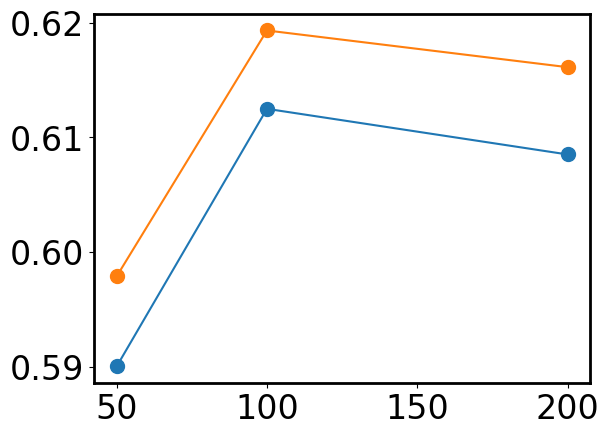

In [74]:
plt.plot(nd_list, ave_dipole_list, '-o')
plt.plot(nd_list, ave_dipole_test_list, '-o')

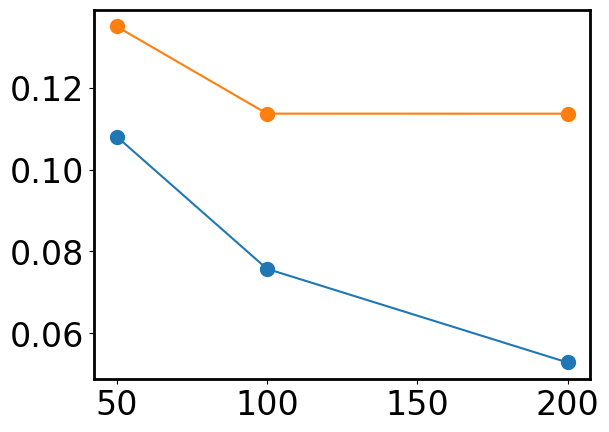

In [75]:
plt.plot(nd_list, error_list, '-o')
plt.plot(nd_list, error_test_list, '-o')

# dipole magnitude histogram

In [69]:
step_index_list

array([  90,  120,  180,  210,  270,  300,  330,  360,  390,  420,  480,
        540,  570,  630,  720,  870,  930,  960,  990, 1020, 1050, 1080,
       1110, 1170])

In [21]:
alpha = 2.26
lambda_reg = 100
descriptor_list = np.load('descriptor_list_shift_train_func200.npy')
descriptor_list_test = np.load('descriptor_list_shift_test_func200.npy')
error, ave_dipole, d_matrix, phi_fit, dipole_predict = fit_water(alpha, lambda_reg, descriptor_list, vec_3d_list_full, phi_train, dipole_Mg_Ne, return_individual_dipole=True)
error_test, ave_dipole_test, phi_fit_test = get_test_error(d_matrix, alpha, descriptor_list_test, vec_3d_list_full_test, vec_3d_list_test, phi_test, dipole_Mg_Ne_test)

In [60]:
dipole_magnitude = np.linalg.norm(dipole_predict, axis = 2)

In [61]:
alpha = 1
lambda_reg = 100
descriptor_list = np.load('descriptor_list_shift_train_func200.npy')
descriptor_list_test = np.load('descriptor_list_shift_test_func200.npy')
error, ave_dipole, d_matrix, phi_fit, dipole_predict = fit_water(alpha, lambda_reg, descriptor_list, vec_3d_list_full, phi_train, dipole_Mg_Ne, return_individual_dipole=True)
error_test, ave_dipole_test, phi_fit_test = get_test_error(d_matrix, alpha, descriptor_list_test, vec_3d_list_full_test, vec_3d_list_test, phi_test, dipole_Mg_Ne_test)

In [62]:
dipole_magnitude_gamma0 = np.linalg.norm(dipole_predict, axis = 2)

In [63]:
np.mean(dipole_magnitude)

0.61039307818879

In [64]:
np.mean(np.linalg.norm(wannier_dipole_individual_list.reshape([-1, 3]), axis = 1))

0.6121612524543149

In [65]:
np.mean(dipole_magnitude_gamma0 )

0.3770421081177929

In [64]:
2.25/0.6085183442313941*0.6121612524543149

2.2634696736413504

In [70]:
np.shape(dipole_predict)

(1200, 63, 3)

In [66]:
wannier_dipole_individual_list = np.load('Mg_wannier_20frame_dipole.npy')

In [67]:
wannier_dipole_individual_list_pure_water = np.load('wannier_dipole_20frame_pure_water.npy')

In [68]:
wannier_dipole_magnitude_pure = np.linalg.norm(wannier_dipole_individual_list_pure_water.reshape([-1, 3]), axis = 1)
wannier_dipole_magnitude = np.linalg.norm(wannier_dipole_individual_list.reshape([-1, 3]), axis = 1)

In [69]:
wannier_dipole_magnitude_tot = np.concatenate((wannier_dipole_magnitude_pure, wannier_dipole_magnitude))

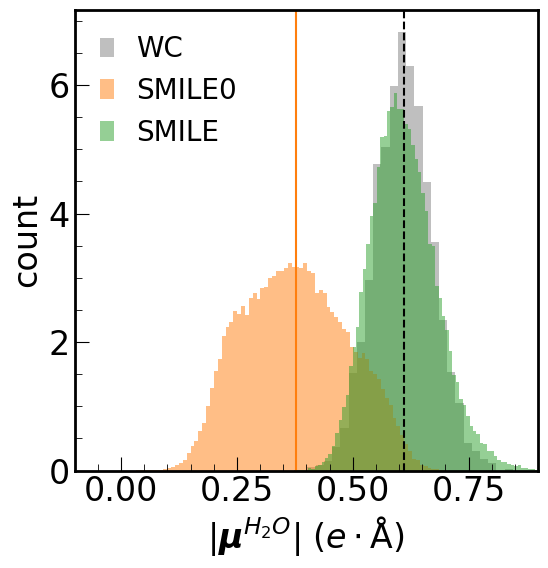

In [71]:
fig, ax = plt.subplots(figsize = (6,6.2))

plt.hist(wannier_dipole_magnitude_tot  , bins = 25, density = True, label = 'WC', color = 'Grey', alpha= 0.5);
plt.hist(dipole_magnitude_gamma0.flatten(), bins = 80 , alpha = 0.5, density = True, label = r'SMILE0', color = 'C1');
plt.hist(dipole_magnitude.flatten(), bins = 80 , alpha = 0.5, density = True, label = r'SMILE', color = 'C2');


#plt.axvline(np.mean(dipole_magnitude), color = 'C0')
plt.axvline(0.61, color = 'Black', linestyle = 'dashed')
plt.axvline(np.mean(dipole_magnitude_gamma0), color = 'C1')

ax.tick_params(axis='x', which='major', direction='in', length=10)
ax.tick_params(axis='x', which='minor', direction='in', length=5)
ax.tick_params(axis='y', which='major', direction='in', length=10)
ax.tick_params(axis='y', which='minor', direction='in', length=5)
ax.minorticks_on()


plt.xlabel(r'|$\boldsymbol{\mu}^{H_2O}$| ($e\cdot\mathrm{\AA}$)')
plt.ylabel('count')
plt.xlim(-0.1, 0.9)
plt.legend(frameon = False)
plt.tight_layout()
plt.savefig('dipole_magnitude_distribution1.png', dpi = 300)

# calculate error on el pot

In [24]:
step_index_list = np.array([  90,  120,  180,  210,  270,  300,  330,  360,  390,  420,  480,
        540,  570,  630,  720,  870,  930,  960,  990, 1020, 1050, 1080,
       1110, 1170])

In [33]:
pot_dft_list = np.load('pot_dft_Mg_20frame.npy')

In [34]:
wannier_dipole_individual_list = np.load('Mg_wannier_20frame_dipole.npy')

## calculate el pot based on ML predicted WC

In [39]:
def get_dipole_predict(alpha, lambda_reg, descriptor_list, vec_3d_list_full, phi_train, dipole_Mg_Ne, return_xyz = False):
    n1, n2 = np.shape(descriptor_list)
    cos_theta_list = np.zeros((n1, 3))
    cos_theta_list[:, 0] = vec_3d_list_full[:, :, 0].reshape(-1)
    cos_theta_list[:, 1] = vec_3d_list_full[:, :, 1].reshape(-1)
    cos_theta_list[:, 2] = vec_3d_list_full[:, :, 2].reshape(-1)
    mat = descriptor_list.reshape([-1, 63, n2])
    shape = np.shape(mat)
    cos_theta_list_full = cos_theta_list.reshape([-1, 63, 3])
    A = np.einsum('ijk, ijl -> ikl', mat, cos_theta_list_full)
    A_reshaped = A.reshape(-1, n2*3)
    m, n = A_reshaped.shape  # Get matrix dimensions
    I = np.eye(n)   # Identity matrix of size n x n
    # Compute regularized solution: x = (A^T A + lambda*I)^-1 A^T b
    mat_inv = np.linalg.inv(A_reshaped.T @ A_reshaped + lambda_reg * I) @ A_reshaped.T
    d_matrix = mat_inv@(phi_train* alpha - dipole_Mg_Ne)
    phi_fit = A_reshaped@d_matrix
    phi_fit = phi_fit.reshape(-1)
    d_matrix = d_matrix.reshape(n2, 3)
    OH1_predict = mat@d_matrix[:, 0]
    OH2_predict = mat@d_matrix[:, 1]
    norm_predict = mat@d_matrix[:, 2]
    
    OH1_contrib_z = OH1_predict*vec_3d_list[:, 0, 2].reshape(shape[0], -1)
    OH2_contrib_z = OH2_predict*vec_3d_list[:, 1, 2].reshape(shape[0], -1)
    norm_contrib_z = norm_predict*vec_3d_list[:, 2, 2].reshape(shape[0], -1)
    
    OH1_contrib_x = OH1_predict*vec_3d_list[:, 0, 0].reshape(shape[0], -1)
    OH2_contrib_x = OH2_predict*vec_3d_list[:, 1, 0].reshape(shape[0], -1)
    norm_contrib_x = norm_predict*vec_3d_list[:, 2, 0].reshape(shape[0], -1)
    
    OH1_contrib_y = OH1_predict*vec_3d_list[:, 0, 1].reshape(shape[0], -1)
    OH2_contrib_y = OH2_predict*vec_3d_list[:, 1, 1].reshape(shape[0], -1)
    norm_contrib_y = norm_predict*vec_3d_list[:, 2, 1].reshape(shape[0], -1)

    shape = np.shape(OH1_contrib_z)
    dipole_predict = np.zeros((shape[0], shape[1], 3))
    dipole_predict[:, :, 2] = OH1_contrib_z + OH2_contrib_z + norm_contrib_z
    dipole_predict[:, :, 0] = OH1_contrib_x + OH2_contrib_x + norm_contrib_x
    dipole_predict[:, :, 1] = OH1_contrib_y + OH2_contrib_y + norm_contrib_y
    if return_xyz == False:
        return dipole_predict, phi_fit
    else:
        return dipole_predict, phi_fit, OH1_predict, OH2_predict, norm_predict   

In [40]:
def calc_el_pot_1d(charge_density, Lz, epsilon_0=0.005526349358057108):
    n_grid = len(charge_density)
    z = np.linspace(0, Lz, n_grid, endpoint=False)
    dz = z[1] - z[0]
    # Fourier transform of charge density
    rho_k = np.fft.fft(charge_density)

    # Define wave numbers (k-space grid)
    k = 2 * np.pi * np.fft.fftfreq(n_grid, d=dz)

    # Solve Poisson’s equation in Fourier space: ϕ_k = -ρ_k / (ε₀ k²)
    phi_k = np.zeros_like(rho_k, dtype=np.complex128)
    
    # Avoid division by zero at k=0 (mean charge mode)
    mask = k != 0
    phi_k[mask] = -rho_k[mask] / (epsilon_0 * k[mask]**2)

    # Transform back to real space
    phi = np.real(np.fft.ifft(phi_k))

    return phi    

In [41]:
def calc_dipole_1d(chargedensity, Lz, nz, gridposition=550, grid_roll = 100):
    chargedensity_roll = chargedensity.copy()
    chargedensity_roll = np.roll(chargedensity_roll, grid_roll)
    dz = Lz/nz
    z = np.linspace(0, Lz, nz, endpoint = False)
    dipole = np.sum(chargedensity_roll*z) * dz
    if(np.abs(dipole)<1e-5): return 0, chargedensity
    dx_dipolcorr = 8 # in gridpoints
    q = dipole / (dx_dipolcorr*dz)
    new_chargedensity = chargedensity.copy()
    new_chargedensity[gridposition] = q / dz
    new_chargedensity[gridposition+dx_dipolcorr] = -q / dz
    return dipole, new_chargedensity

In [42]:
def get_gaussian_charge_shift(dipole_predict, core_center_list, O_pos_list, H_pos_list, Mg_pos, z_Ne, sigma_Mg, sigma_Ne, sigma_O, sigma_H, sigma_Mg_el, sigma_Ne_el, sigma_water_el, alpha_Mg, alpha_Ne, alpha_water, total_dipole, Lz, nz = 648, dipole_mul = 1, shift = True):
    dz = Lz/nz
    z = np.linspace(0, Lz, nz, endpoint=False)
    rho  = np.zeros_like(z)
    n_roll = 90
    z_roll = n_roll*dz
    # water 
    for i in range(63):
        # el
        r_dipole = dipole_mul * dipole_predict[i] / 8
        pos_z = core_center_list[i] + r_dipole[2]
        if shift == True:
            pos_z += alpha_water * total_dipole
        q = 8
        gaussian = (q / (np.sqrt(2 * np.pi) * sigma_water_el)) * np.exp(-0.5 * ((z - (pos_z+z_roll)) / sigma_water_el)**2)
        rho += gaussian
    # water core
    for i in range(63):
        pos_z = O_pos_list[i]
        q = -6
        gaussian = (q / (np.sqrt(2 * np.pi) * sigma_O)) * np.exp(-0.5 * ((z - (pos_z+z_roll)) / sigma_O)**2)
        rho += gaussian
    for i in range(126):
        pos_z = H_pos_list[i]
        q = -1
        gaussian = (q / (np.sqrt(2 * np.pi) * sigma_H)) * np.exp(-0.5 * ((z - (pos_z+z_roll)) / sigma_H)**2)
        rho += gaussian

    # charge of Ne
    # core
    q = -(8-2/24)
    pos_z = z_Ne
    gaussian = (q / (np.sqrt(2 * np.pi) * sigma_Ne)) * np.exp(-0.5 * ((z - (pos_z+z_roll)) / sigma_Ne)**2)
    rho += 12*gaussian
    #el
    q = 8
    pos_z = z_Ne
    if shift == True:
        pos_z += alpha_Ne * total_dipole
    gaussian = (q / (np.sqrt(2 * np.pi) * sigma_Ne_el)) * np.exp(-0.5 * ((z - (pos_z+z_roll)) / sigma_Ne_el)**2)
    rho += 12*gaussian

    q = -(8-2/24)
    pos_z = 0
    gaussian = (q / (np.sqrt(2 * np.pi) * sigma_Ne)) * np.exp(-0.5 * ((z - (pos_z+z_roll)) / sigma_Ne)**2)
    rho += 12*gaussian

    q = 8
    pos_z = 0
    if shift == True:
        pos_z += alpha_Ne * total_dipole
    gaussian = (q / (np.sqrt(2 * np.pi) * sigma_Ne_el)) * np.exp(-0.5 * ((z - (pos_z+z_roll)) / sigma_Ne_el)**2)
    rho += 12*gaussian

    # charge of Mg
    q = 6
    pos_z = Mg_pos
    if shift == True:
        pos_z += alpha_Mg * total_dipole
    gaussian = (q / (np.sqrt(2 * np.pi) * sigma_Mg_el)) * np.exp(-0.5 * ((z - (pos_z+z_roll)) / sigma_Mg_el)**2)
    rho += gaussian    
    # core of Mg
    q = -8
    pos_z = Mg_pos
    gaussian = (q / (np.sqrt(2 * np.pi) * sigma_Mg)) * np.exp(-0.5 * ((z - (pos_z+z_roll)) / sigma_Mg)**2)
    rho += gaussian         

    rho = np.roll(rho, -n_roll)
    return z, rho

In [43]:
core_center_list = np.reshape(core_center_list, (-1, 63))

In [48]:
def get_pot_error_surf(dipole_predict, phi_fit, step_index_list, core_center_list, sigma_Mg, sigma_Ne, sigma_H, sigma_O, sigma_H_surf, sigma_O_surf, sigma_Mg_el, sigma_Ne_el, sigma_water_el, sigma_water_el_surf):
    error_list = []
    phi_list = []
    for i, step_index in enumerate(step_index_list):
        index_O_surf = np.where(core_center_list[step_index] < 3)
        index_O_surf2 = np.where(core_center_list[step_index] > 22)
        index_H_surf = np.where(H_pos_list[step_index, :, 2] < 3)
        index_H_surf2 = np.where(H_pos_list[step_index, :, 2] > 22)
        sigma_core_list = np.zeros(63+126)
        sigma_core_list[:126] = sigma_H
        sigma_core_list[126:] = sigma_O
        sigma_el_list = np.zeros(63)
        sigma_el_list[:] = sigma_water_el
        sigma_el_list[index_O_surf] = sigma_water_el_surf
        sigma_el_list[index_O_surf2] = sigma_water_el_surf 
        sigma_core_list[126+np.array(index_O_surf)] = sigma_O_surf
        sigma_core_list[126+np.array(index_O_surf2)] = sigma_O_surf
        sigma_core_list[np.array(index_H_surf)] = sigma_H_surf
        sigma_core_list[np.array(index_H_surf2)] = sigma_H_surf

        z, rho = get_gaussian_charge_surf(dipole_predict[step_index], core_center_list[step_index], O_pos_list[step_index, :, 2], H_pos_list[step_index, :, 2], Mg_pos_list[step_index, 0, 2], z_Ne, sigma_Mg, sigma_Ne, sigma_core_list, sigma_Mg_el, sigma_Ne_el, sigma_el_list, alpha_Mg, alpha_Ne, alpha_water, (phi_fit[step_index]+dipole_Mg_Ne[step_index])*(1-alpha)/alpha, Lz, nz = 648, dipole_mul = 1, shift = True)
        dipole_shift, rho_shift= calc_dipole_1d(rho, Lz, 648, gridposition=530, grid_roll = 100)  
        phi = calc_el_pot_1d(-rho_shift/Lx/Ly, Lz)  
        phi_diff = phi - phi[500] - (pot_dft_list[i] - pot_dft_list[i][500])
        error = np.linalg.norm(phi_diff[0:400])
        error_list.append(error)
        phi_list.append(phi)
    error = np.mean(error_list)
    phi_mean = np.mean(phi_list, axis = 0)
    return error, phi_mean

In [50]:
sigma_Ne = 1.3/4
sigma_Ne_el = 0.45 #0.4289 #0.45 #0.45 #0.462

sigma_water = 0.30857
#sigma_O = 0.5
#sigma_H = 0.4
sigma_O = 0.32 #0.34 #sigma_water
sigma_H =  0.38 #0.25 #sigma_water
sigma_water_el = 0.521 #0.5111 #0.5131 #0.5111

sigma_Mg = 0.84
sigma_Mg_el = 0.78

sigma_O_surf = 0.32 #0.376 #sigma_O
sigma_H_surf = 0.51 #sigma_H

sigma_water_el_surf = 0.55 #0.526 #0.5263 #0.5111

In [52]:
def get_gaussian_charge_surf(dipole_predict, core_center_list, O_pos_list, H_pos_list, Mg_pos, z_Ne, sigma_Mg, sigma_Ne, sigma_core_list, sigma_Mg_el, sigma_Ne_el, sigma_el_list, alpha_Mg, alpha_Ne, alpha_water, total_dipole, Lz, nz = 648, dipole_mul = 1, shift = True):
    dz = Lz/nz
    z = np.linspace(0, Lz, nz, endpoint=False)
    rho  = np.zeros_like(z)
    n_roll = 90
    z_roll = n_roll*dz
    # water 
    for i in range(63):
        # el
        r_dipole = dipole_mul * dipole_predict[i] / 8
        pos_z = core_center_list[i] + r_dipole[2]
        if shift == True:
            pos_z += alpha_water * total_dipole
        q = 8
        gaussian = (q / (np.sqrt(2 * np.pi) * sigma_el_list[i])) * np.exp(-0.5 * ((z - (pos_z+z_roll)) / sigma_el_list[i])**2)
        rho += gaussian
    # water core
    for i in range(63):
        pos_z = O_pos_list[i]
        q = -6
        gaussian = (q / (np.sqrt(2 * np.pi) * sigma_core_list[i+126])) * np.exp(-0.5 * ((z - (pos_z+z_roll)) / sigma_core_list[i+126])**2)
        rho += gaussian
    for i in range(126):
        pos_z = H_pos_list[i]
        q = -1
        gaussian = (q / (np.sqrt(2 * np.pi) * sigma_core_list[i])) * np.exp(-0.5 * ((z - (pos_z+z_roll)) / sigma_core_list[i])**2)
        rho += gaussian

    # charge of Ne
    # core
    q = -(8-2/24)
    pos_z = z_Ne
    gaussian = (q / (np.sqrt(2 * np.pi) * sigma_Ne)) * np.exp(-0.5 * ((z - (pos_z+z_roll)) / sigma_Ne)**2)
    rho += 12*gaussian
    #el
    q = 8
    pos_z = z_Ne
    if shift == True:
        pos_z += alpha_Ne * total_dipole
    gaussian = (q / (np.sqrt(2 * np.pi) * sigma_Ne_el)) * np.exp(-0.5 * ((z - (pos_z+z_roll)) / sigma_Ne_el)**2)
    rho += 12*gaussian

    q = -(8-2/24)
    pos_z = 0
    gaussian = (q / (np.sqrt(2 * np.pi) * sigma_Ne)) * np.exp(-0.5 * ((z - (pos_z+z_roll)) / sigma_Ne)**2)
    rho += 12*gaussian

    q = 8
    pos_z = 0
    if shift == True:
        pos_z += alpha_Ne * total_dipole
    gaussian = (q / (np.sqrt(2 * np.pi) * sigma_Ne_el)) * np.exp(-0.5 * ((z - (pos_z+z_roll)) / sigma_Ne_el)**2)
    rho += 12*gaussian

    # charge of Mg
    q = 6
    pos_z = Mg_pos
    if shift == True:
        pos_z += alpha_Mg * total_dipole
    gaussian = (q / (np.sqrt(2 * np.pi) * sigma_Mg_el)) * np.exp(-0.5 * ((z - (pos_z+z_roll)) / sigma_Mg_el)**2)
    rho += gaussian    
    # core of Mg
    q = -8
    pos_z = Mg_pos
    gaussian = (q / (np.sqrt(2 * np.pi) * sigma_Mg)) * np.exp(-0.5 * ((z - (pos_z+z_roll)) / sigma_Mg)**2)
    rho += gaussian         

    rho = np.roll(rho, -n_roll)
    return z, rho

In [59]:
mean_Mg_pos = np.mean(Mg_pos_list[step_index_list,:, 2])

In [60]:
alpha = 2.25
lambda_reg = 100
dipole_predict, phi_fit, OH1_predict, OH2_predict, norm_predict = get_dipole_predict(alpha, lambda_reg, descriptor_list, vec_3d_list_full, phi_train, dipole_Mg_Ne, return_xyz = True)
error, phi_mean = get_pot_error_surf(dipole_predict, phi_fit, step_index_list, core_center_list, sigma_Mg, sigma_Ne, sigma_H, sigma_O, sigma_H_surf, sigma_O_surf, sigma_Mg_el, sigma_Ne_el, sigma_water_el, sigma_water_el_surf)

In [57]:
alpha =1
lambda_reg = 100
dipole_predict_gamma0, phi_fit_gamma0, OH1_predict, OH2_predict, norm_predict = get_dipole_predict(alpha, lambda_reg, descriptor_list, vec_3d_list_full, phi_train, dipole_Mg_Ne, return_xyz = True)
error_gamma0, phi_mean_gamma0 = get_pot_error_surf(dipole_predict_gamma0, phi_fit_gamma0, step_index_list, core_center_list, sigma_Mg, sigma_Ne, sigma_H, sigma_O, sigma_H_surf, sigma_O_surf, sigma_Mg_el, sigma_Ne_el, sigma_water_el, sigma_water_el_surf)


<>:23: SyntaxWarning: invalid escape sequence '\ '
<>:24: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\ '
<>:24: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_14976/2405766862.py:23: SyntaxWarning: invalid escape sequence '\ '
  plt.xlabel('$z\ (\mathrm{\AA})$')
/tmp/ipykernel_14976/2405766862.py:24: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$\phi\ (\mathrm{V})$')


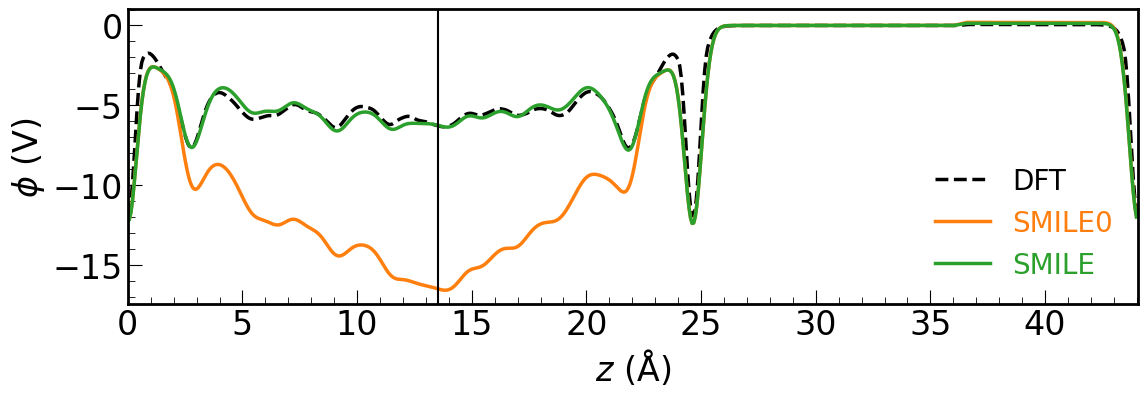

In [62]:
fig, ax = plt.subplots(figsize = (12,4.5))

#plt.plot(z, phi_list[min_index] - phi_list[min_index][500], label = 'ML', color = 'Red')
plt.plot(z, np.mean(pot_dft_list, axis = 0) - np.mean(pot_dft_list, axis = 0)[500], '--', label = 'DFT', color = 'Black', linewidth = 2.5)

plt.plot(z, phi_mean_gamma0 - phi_mean_gamma0[500], label = 'SMILE0', color = 'C1', linewidth = 2.5)

plt.plot(z, phi_mean - phi_mean[500], label = r'SMILE', color = 'C2', linewidth = 2.5)


#plt.axvline(3)
#plt.axvline(22)

plt.axvline(mean_Mg_pos, color = 'Black')
plt.xlim(0, Lz)

ax.tick_params(axis='x', which='major', direction='in', length=10)
ax.tick_params(axis='x', which='minor', direction='in', length=5)
ax.tick_params(axis='y', which='major', direction='in', length=10)
ax.tick_params(axis='y', which='minor', direction='in', length=5)
ax.minorticks_on()

plt.xlabel('$z\ (\mathrm{\AA})$')
plt.ylabel('$\phi\ (\mathrm{V})$')
legend = plt.legend(frameon = False, handlelength=2)

legend.get_texts()[0].set_color("Black")
legend.get_texts()[1].set_color("C1")
legend.get_texts()[2].set_color("C2")


plt.tight_layout()
plt.savefig('Mg-pot.png', dpi = 300)

In [1064]:
rho_wannier_list = np.load('charge_density_wannier_gaussian.npy')

In [1065]:
alpha = 2.18
lambda_reg = 1
dipole_predict, phi_fit = get_dipole_predict(alpha, lambda_reg, descriptor_list, vec_3d_list_full, phi_train)


Lx = 8.464068
Ly = 8.464068
Lz = 44.055096

z_Ne = 24.656269320469203

sigma_Ne = 1.3/4
sigma_Ne_el = 0.462 #sigma_Ne*1.32
#sigma_water = 1.7/4
#sigma_water_el = sigma_water*1.3
sigma_water = 0.29
sigma_O = sigma_water
sigma_H = sigma_water
sigma_water_el = 0.53

i = 19
step_index = step_index_list[i]

alpha_Ne = 1/(64*8+24*8)
alpha_water = 1/(64*8+24*8)
z, rho = get_gaussian_charge_shift(dipole_predict[step_index], core_center_list[step_index], O_pos_list[step_index, :, 2], H_pos_list[step_index, :, 2], z_Ne, sigma_Ne, sigma_O, sigma_H, sigma_Ne_el, sigma_water_el, alpha_Ne, alpha_water, phi_fit[step_index]*(1-alpha)/alpha, Lz, nz = 648, dipole_mul = 1, shift = True)
dipole_shift, rho_shift= calc_dipole_1d(rho, Lz, 648, gridposition=530, grid_roll = 100)  
phi = calc_el_pot_1d(-rho_shift/Lx/Ly, Lz)    


z, rho = get_gaussian_charge_shift(dipole_predict[step_index], core_center_list[step_index], O_pos_list[step_index, :, 2], H_pos_list[step_index, :, 2], z_Ne, sigma_Ne, sigma_O, sigma_H, sigma_Ne_el, sigma_water_el, alpha_Ne, alpha_water, phi_fit[step_index]*(1-alpha)/alpha, Lz, dipole_mul = 1, shift = False)
dipole_noshift, rho_noshift = calc_dipole_1d(rho, Lz, 648, gridposition=530, grid_roll = 100)  
phi_noshift = calc_el_pot_1d(-rho_noshift/Lx/Ly, Lz)    

In [1102]:
job = pr.load('pure_water_20frame_corr_'+str(step_index))
rho_core, rho_dft = get_dft_charge_density(job, sigma_O, sigma_H, sigma_Ne, Lx, Ly, Lz, 648, grid_roll = 100)
chg_dft = job.get_charge_density().get_average_along_axis(2)

2025-06-10 14:07:03,535 - pyiron_log - DEBUG - sql_query: {'job': 'pure_water_20frame_corr_1140', 'project': '/cmmc/ptmp/jyang/water_Ne/water_Ne/'}
2025-06-10 14:07:03,547 - pyiron_log - INFO - Reconnecting to DB; connection was closed.
2025-06-10 14:07:03,934 - pyiron_log - WARNING - Could not access indices, returning None!
2025-06-10 14:07:03,934 - pyiron_log - WARNING - Could not access indices, returning None!
2025-06-10 14:07:03,952 - pyiron_log - WARNING - Could not access indices, returning None!
2025-06-10 14:07:03,952 - pyiron_log - WARNING - Could not access indices, returning None!
2025-06-10 14:07:03,953 - pyiron_log - DEBUG - Not supported parameter used!


In [ ]:
phi_dft = calc_el_pot_1d(rho_dft, Lz) 

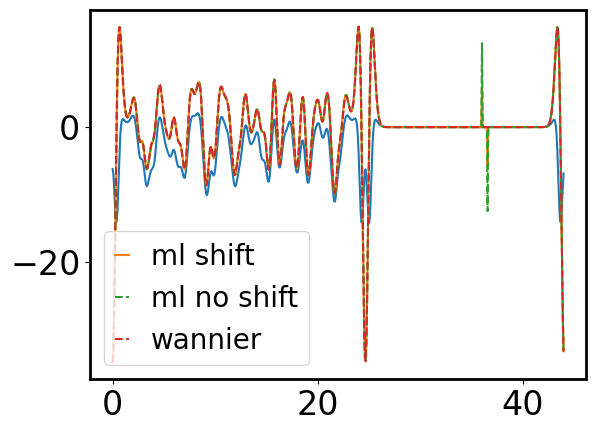

In [1107]:
plt.plot(z, rho_dft)
#plt.plot(z, chg_dft*Lx*Ly)
#plt.plot(z, rho_core)
plt.plot(z, rho_shift, label = 'ml shift')
plt.plot(z, rho_noshift, '--', label = 'ml no shift')
plt.plot(z, rho_wannier_list[i], '--', label = 'wannier')
plt.legend()

(-0.4, 0.4)

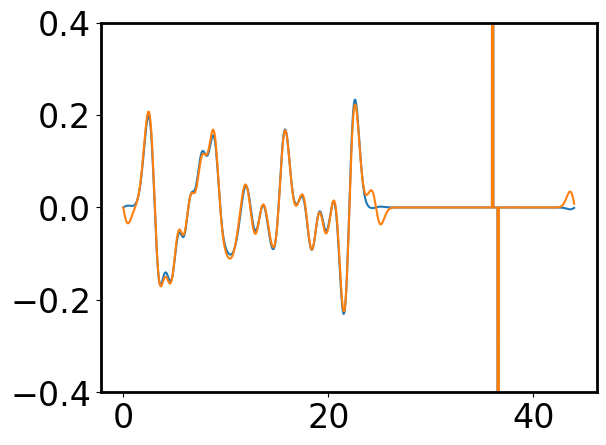

In [1076]:
plt.plot(z, rho_noshift - rho_wannier_list[i])
plt.plot(z, rho_shift - rho_wannier_list[i])

plt.ylim(-0.4, 0.4)

In [1101]:
def get_dft_charge_density(job, sigma_O, sigma_H, sigma_Ne, Lx, Ly, Lz, nz, grid_roll = 100):
    chg = job.get_charge_density()
    struct = job.get_structure(-1)
    rho_core = np.zeros(nz)
    
    index_O = struct.select_index('O')
    index_H = struct.select_index('H')
    index_Ne = struct.select_index('Ne')
    z_grid = np.linspace(0, Lz, nz, endpoint = False)
    dz = z_grid[1] - z_grid[0]
    
    n_roll = 100
    z_roll = n_roll*dz

    for iO in index_O:
        pos_z = struct.positions[iO, 2]
        q = -6
        gaussian = (q / (np.sqrt(2 * np.pi) * sigma_O)) * np.exp(-0.5 * ((z - (pos_z+z_roll)) / sigma_O)**2)
        rho_core += gaussian
    for iH in index_H:
        pos_z = struct.positions[iH, 2]
        q = -1
        gaussian = (q / (np.sqrt(2 * np.pi) * sigma_H)) * np.exp(-0.5 * ((z - (pos_z+z_roll)) / sigma_H)**2)
        rho_core += gaussian
    for iNe in index_Ne:
        pos_z = struct.positions[iNe, 2]
        q = -8
        gaussian = (q / (np.sqrt(2 * np.pi) * sigma_Ne)) * np.exp(-0.5 * ((z - (pos_z+z_roll)) / sigma_Ne)**2)
        rho_core += gaussian
    rho_core = np.roll(rho_core, -n_roll)
    rho = rho_core + chg.get_average_along_axis(2)*Lx*Ly
    return rho_core, rho

In [989]:
def get_local_field(dipole_predict, field, core_center_list, O_pos_list, H_pos_list, z_Ne, sigma_Ne, sigma_O, sigma_H, sigma_Ne_el, sigma_water_el, alpha_Ne, alpha_water, total_dipole, Lz, nz = 648, dipole_mul = 1, shift = True):
    dz = Lz/nz
    z = np.linspace(0, Lz, nz, endpoint=False)
    rho  = np.zeros_like(z)
    n_roll = 90
    z_roll = n_roll*dz
    local_field_list = []
    # water
    for i in range(64):
        r_dipole = dipole_mul * dipole_predict[i] / 8
        pos_z = core_center_list[i] + r_dipole[2]
        index_z = int(np.round(pos_z/Lz*nz))
        local_field_list.append(field[index_z])
    # Ne 
    pos_z = 0
    index_z = int(np.round(pos_z/Lz*nz))
    for i in range(12):
        local_field_list.append(field[index_z])
    pos_z = z_Ne
    index_z = int(np.round(pos_z/Lz*nz))
    for i in range(12):
        local_field_list.append(field[index_z])
    return local_field_list
       

In [1018]:
def get_gaussian_charge_shift_field(dipole_predict, field, core_center_list, O_pos_list, H_pos_list, z_Ne, sigma_Ne, sigma_O, sigma_H, sigma_Ne_el, sigma_water_el, alpha_Ne, alpha_water, total_dipole, Lz, nz = 648, dipole_mul = 1, shift = True):
    dz = Lz/nz
    z = np.linspace(0, Lz, nz, endpoint=False)
    rho  = np.zeros_like(z)
    n_roll = 90
    z_roll = n_roll*dz
    local_field_list = get_local_field(dipole_predict, field, core_center_list, O_pos_list, H_pos_list, z_Ne, sigma_Ne, sigma_O, sigma_H, sigma_Ne_el, sigma_water_el, alpha_Ne, alpha_water, total_dipole, Lz, nz = 648, dipole_mul = 1, shift = True)
    E_ave = total_dipole/(64*8*alpha_water + 24*8*alpha_Ne)
    E_ave_local = np.mean(local_field_list)
    E0 = E_ave - E_ave_local
    
    # water 
    for i in range(64):
        # el
        r_dipole = dipole_mul * dipole_predict[i] / 8
        pos_z = core_center_list[i] + r_dipole[2]
        index_z = np.round(pos_z/Lz*nz)
        local_field_list.append(index_z)
        if shift == True:
            pos_z += alpha_water * (E0 + local_field_list[i])
        q = 8
        gaussian = (q / (np.sqrt(2 * np.pi) * sigma_water_el)) * np.exp(-0.5 * ((z - (pos_z+z_roll)) / sigma_water_el)**2)
        rho += gaussian
    # water core
    for i in range(64):
        pos_z = O_pos_list[i]
        q = -6
        gaussian = (q / (np.sqrt(2 * np.pi) * sigma_O)) * np.exp(-0.5 * ((z - (pos_z+z_roll)) / sigma_O)**2)
        rho += gaussian
    for i in range(128):
        pos_z = H_pos_list[i]
        q = -1
        gaussian = (q / (np.sqrt(2 * np.pi) * sigma_H)) * np.exp(-0.5 * ((z - (pos_z+z_roll)) / sigma_H)**2)
        rho += gaussian

    # charge of Ne
    # core
    q = -(8)
    pos_z = z_Ne
    gaussian = (q / (np.sqrt(2 * np.pi) * sigma_Ne)) * np.exp(-0.5 * ((z - (pos_z+z_roll)) / sigma_Ne)**2)
    rho += 12*gaussian
    #el
    q = 8
    pos_z = z_Ne
    if shift == True:
        pos_z += alpha_Ne * (E0 + local_field_list[64+12])
    gaussian = (q / (np.sqrt(2 * np.pi) * sigma_Ne_el)) * np.exp(-0.5 * ((z - (pos_z+z_roll)) / sigma_Ne_el)**2)
    rho += 12*gaussian

    q = -(8)
    pos_z = 0
    gaussian = (q / (np.sqrt(2 * np.pi) * sigma_Ne)) * np.exp(-0.5 * ((z - (pos_z+z_roll)) / sigma_Ne)**2)
    rho += 12*gaussian

    q = 8
    pos_z = 0
    if shift == True:
        pos_z += alpha_Ne * (E0 + local_field_list[64])
    gaussian = (q / (np.sqrt(2 * np.pi) * sigma_Ne_el)) * np.exp(-0.5 * ((z - (pos_z+z_roll)) / sigma_Ne_el)**2)
    rho += 12*gaussian
       
    rho = np.roll(rho, -n_roll)
    return z, rho

In [990]:

local_field_list = get_local_field(dipole_predict[step_index], field, core_center_list[step_index], O_pos_list[step_index, :, 2], H_pos_list[step_index, :, 2], z_Ne, sigma_Ne, sigma_O, sigma_H, sigma_Ne_el, sigma_water_el, alpha_Ne, alpha_water, phi_fit[step_index]*(1-alpha)/alpha, Lz, nz = 648, dipole_mul = 1, shift = True)


In [992]:
np.mean(local_field_list)

-1.3568331068642054

In [999]:
local_field_list_steps = []
for i in range(20):
    step_index = step_index_list[i]
    z, rho = get_gaussian_charge_shift(dipole_predict[step_index], core_center_list[step_index], O_pos_list[step_index, :, 2], H_pos_list[step_index, :, 2], z_Ne, sigma_Ne, sigma_O, sigma_H, sigma_Ne_el, sigma_water_el, alpha_Ne, alpha_water, phi_fit[step_index]*(1-alpha)/alpha, Lz, dipole_mul = 1, shift = False)
    dipole_noshift, rho_corr = calc_dipole_1d(rho, Lz, 648, gridposition=530, grid_roll = 100)  
    phi_noshift = calc_el_pot_1d(-rho_corr/Lx/Ly, Lz)    
    field = (-2*phi_noshift+np.roll(phi_noshift, 1)+np.roll(phi_noshift, -1))/(z[1] - z[0])/2
    local_field_list = get_local_field(dipole_predict[step_index], field, core_center_list[step_index], O_pos_list[step_index, :, 2], H_pos_list[step_index, :, 2], z_Ne, sigma_Ne, sigma_O, sigma_H, sigma_Ne_el, sigma_water_el, alpha_Ne, alpha_water, phi_fit[step_index]*(1-alpha)/alpha, Lz, nz = 648, dipole_mul = 1, shift = True)
    local_field_list_steps.append(local_field_list)

In [1003]:
local_field_list_steps = np.array(local_field_list_steps )

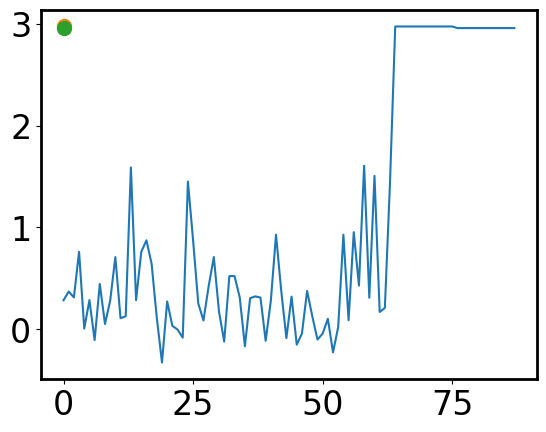

In [1017]:
plt.plot(local_field_list_steps[0])
plt.plot(local_field_list_steps[0, 64], 'o')
plt.plot(local_field_list_steps[0, 64+12], 'o')

In [1036]:
alpha = 1
lambda_reg = 1
dipole_predict, phi_fit = get_dipole_predict(alpha, lambda_reg, descriptor_list, vec_3d_list_full, phi_train)
    

In [1037]:
Lx = 8.464068
Ly = 8.464068
Lz = 44.055096

z_Ne = 24.656269320469203

sigma_Ne = 1.3/4
sigma_Ne_el = 0.462 #sigma_Ne*1.32
#sigma_water = 1.7/4
#sigma_water_el = sigma_water*1.3
sigma_water = 0.29
sigma_O = sigma_water
sigma_H = sigma_water
sigma_water_el = 0.53

i = 19
step_index = step_index_list[i]

alpha_Ne = 1/(64*8+24*8)
alpha_water = 1/(64*8+24*8)
z, rho = get_gaussian_charge_shift(dipole_predict[step_index], core_center_list[step_index], O_pos_list[step_index, :, 2], H_pos_list[step_index, :, 2], z_Ne, sigma_Ne, sigma_O, sigma_H, sigma_Ne_el, sigma_water_el, alpha_Ne, alpha_water, phi_fit[step_index]*(1-alpha)/alpha, Lz, dipole_mul = 1, shift = False)
dipole_noshift, rho_corr = calc_dipole_1d(rho, Lz, 648, gridposition=530, grid_roll = 100)  
phi_noshift = calc_el_pot_1d(-rho_corr/Lx/Ly, Lz)    
field = (-2*phi_noshift+np.roll(phi_noshift, 1)+np.roll(phi_noshift, -1))/(z[1] - z[0])/2
    
z, rho = get_gaussian_charge_shift_field(dipole_predict[step_index], field, core_center_list[step_index], O_pos_list[step_index, :, 2], H_pos_list[step_index, :, 2], z_Ne, sigma_Ne, sigma_O, sigma_H, sigma_Ne_el, sigma_water_el, alpha_Ne, alpha_water, phi_fit[step_index]*(1-alpha)/alpha, Lz, nz = 648, dipole_mul = 1, shift = True)
dipole_shift, rho_corr = calc_dipole_1d(rho, Lz, 648, gridposition=530, grid_roll = 100)  
phi = calc_el_pot_1d(-rho_corr/Lx/Ly, Lz)    




(0.0, 44.055096)

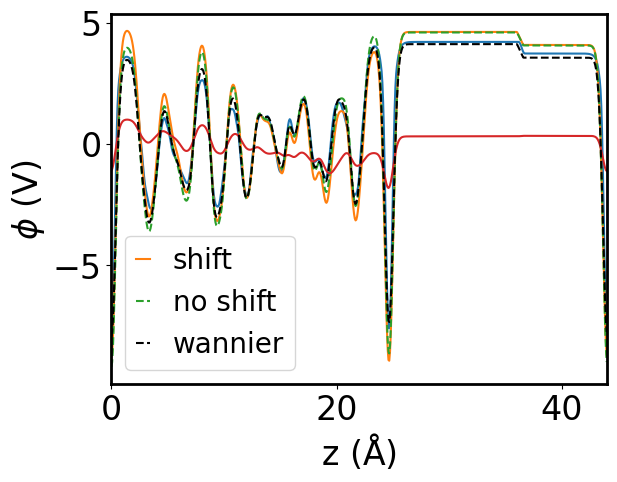

In [1038]:
plt.plot(z, pot_list[i] - np.mean(pot_list[i][50:315]))
plt.plot(z, phi - np.mean(phi[50:315]), label = 'shift')
plt.plot(z, phi_noshift - np.mean(phi_noshift[50:315]), '--', label = 'no shift')
plt.plot(z, phi-phi_wannier_list[i])

plt.plot(z, phi_wannier_list[i]-np.mean(phi_wannier_list[i][50:315]), '--', color = 'Black', label = 'wannier')
plt.legend()
plt.xlabel(r'z ($\mathrm{\AA}$)')
plt.ylabel(r'$\phi$ (V)')
plt.xlim(0, Lz)

(0.0, 44.055096)

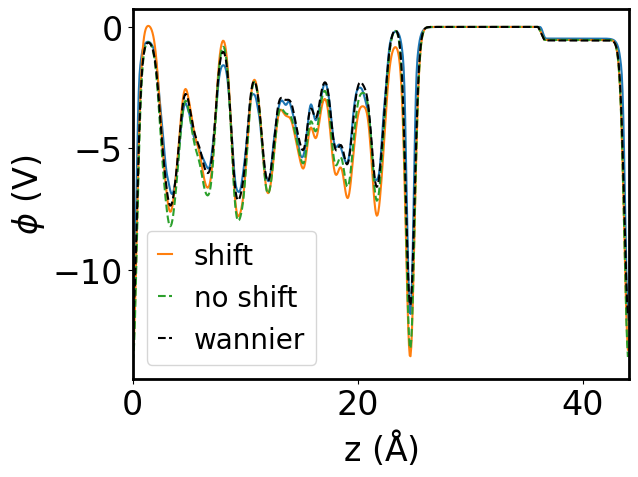

In [1039]:
plt.plot(z, pot_list[i] - pot_list[i][500])
plt.plot(z, phi - phi[500], label = 'shift')
plt.plot(z, phi_noshift - phi_noshift[500], '--', label = 'no shift')


plt.plot(z, phi_wannier_list[i]-phi_wannier_list[i][500], '--', color = 'Black', label = 'wannier')
plt.legend()
plt.xlabel(r'z ($\mathrm{\AA}$)')
plt.ylabel(r'$\phi$ (V)')
plt.xlim(0, Lz)

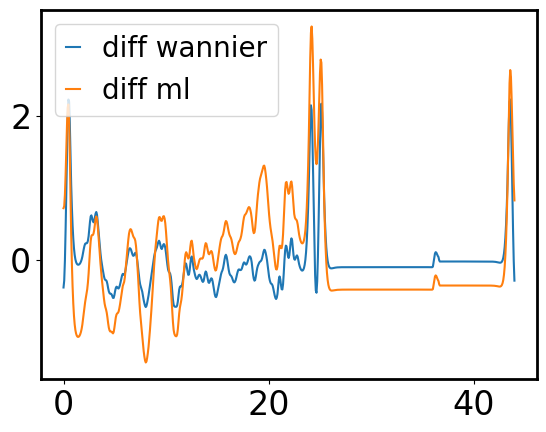

In [1040]:
plt.plot(z, pot_list[i]-phi_wannier_list[i], label = 'diff wannier')
plt.plot(z, pot_list[i]-phi, label = 'diff ml')
plt.legend()

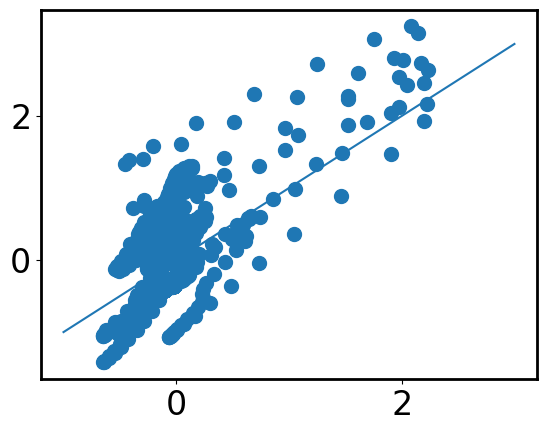

In [1043]:
plt.scatter(pot_list[i]-phi_wannier_list[i], pot_list[i]-phi)
plt.plot([-1, 3], [-1, 3])

## minimize error in elecrostatic potential

In [922]:
def get_pot_error(dipole_predict, step_index_list, pot_list, phi_fit, alpha_water, alpha_Ne, sigma_Ne, sigma_water, sigma_Ne_el, sigma_water_el):
    phi_error_list = []
    for i, step_index in enumerate(step_index_list):
        z, rho = get_gaussian_charge_shift(dipole_predict[step_index], core_center_list[step_index], O_pos_list[step_index, :, 2], H_pos_list[step_index, :, 2], z_Ne, sigma_Ne, sigma_O, sigma_H, sigma_Ne_el, sigma_water_el, alpha_Ne, alpha_water, phi_fit[step_index]*(1-alpha)/alpha, Lz, nz = 648, dipole_mul = 1, shift = True)
        dipole_shift, rho_corr = calc_dipole_1d(rho, Lz, 648, gridposition=530, grid_roll = 100)  
        phi = calc_el_pot_1d(-rho_corr/Lx/Ly, Lz)    
        phi_diff = phi - np.mean(phi[50:315]) - (pot_list[i]-np.mean(pot_list[i][50:315]))
        phi_error = np.linalg.norm(phi_diff[50:315])
        phi_error_list.append(phi_error)
    return phi_error_list

## function of alpha

In [902]:
alpha_list = np.linspace(0.5, 2, 10)
lambda_reg = 1
alpha_Ne = 1/(64*8+24*8)
alpha_water = 1/(64*8+24*8)

In [903]:
sigma_Ne = 1.3/4
sigma_Ne_el = 0.462 #sigma_Ne*1.32
#sigma_water = 1.7/4
#sigma_water_el = sigma_water*1.3
sigma_water = 0.29
sigma_O = sigma_water
sigma_H = sigma_water
sigma_water_el = 0.53

In [904]:
phi_alpha_error_list = []
for alpha in alpha_list:
    dipole_predict, phi_fit = get_dipole_predict(alpha, lambda_reg, descriptor_list, vec_3d_list_full, phi_train)
    dipole_predict = np.reshape(dipole_predict, (-1, 64, 3)) 
    phi_fit = dipole_predict[:,:,2].sum(axis=1)
    phi_error_list = get_pot_error(dipole_predict, step_index_list, pot_list, phi_fit, alpha_water, alpha_Ne, sigma_Ne, sigma_water, sigma_Ne_el, sigma_water_el)
    phi_alpha_error_list.append(phi_error_list)

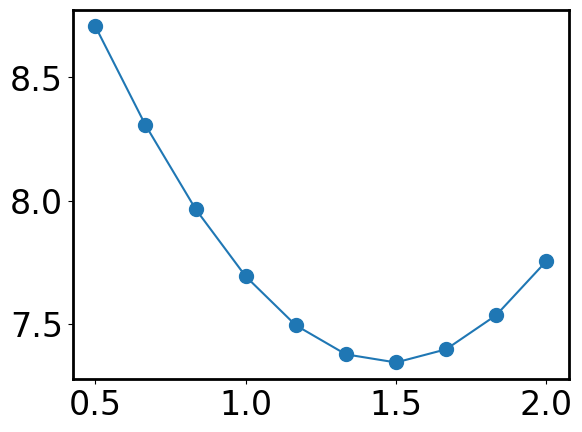

In [905]:
plt.plot(alpha_list, np.mean(phi_alpha_error_list, axis = 1), '-o')

In [906]:
np.argmin(np.mean(phi_alpha_error_list, axis = 1))

6

In [907]:
alpha_list[np.argmin(np.mean(phi_alpha_error_list, axis = 1))]

1.5

In [908]:
np.min(np.mean(phi_alpha_error_list, axis = 1))

7.342912490977332

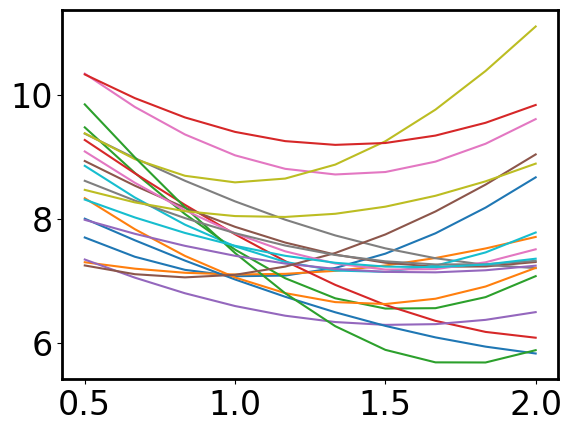

In [909]:
for i in range(20):
    plt.plot(alpha_list, np.array(phi_alpha_error_list)[:, i])

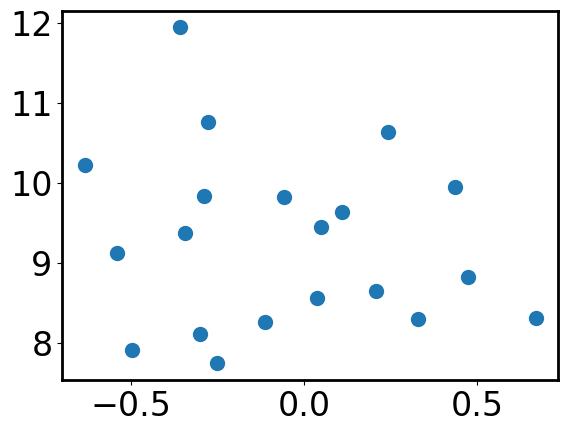

In [840]:
plt.scatter(phi_train[step_index_list], np.array(phi_alpha_error_list)[1, :])

## function of polarizability

In [923]:
sigma_Ne = 1.3/4
sigma_Ne_el = 0.462 #sigma_Ne*1.32
#sigma_water = 1.7/4
#sigma_water_el = sigma_water*1.3
sigma_water = 0.29
sigma_O = sigma_water
sigma_H = sigma_water
sigma_water_el = 0.53

In [929]:
alpha = 2.18295766701008
lambda_reg = 1
alpha_water_list = np.linspace(0.5, 1, 10)/(64*8)
phi_alpha_water_error_list = []
for alpha_water in alpha_water_list:
    alpha_Ne = (1-alpha_water*64*8)/(24*8)
    dipole_predict, phi_fit = get_dipole_predict(alpha, lambda_reg, descriptor_list, vec_3d_list_full, phi_train)
    dipole_predict = np.reshape(dipole_predict, (-1, 64, 3)) 
    phi_fit = dipole_predict[:,:,2].sum(axis=1)
    phi_error_list = get_pot_error(dipole_predict, step_index_list, pot_list, phi_fit, alpha_water, alpha_Ne, sigma_Ne, sigma_water, sigma_Ne_el, sigma_water_el)
    phi_alpha_water_error_list.append(phi_error_list)

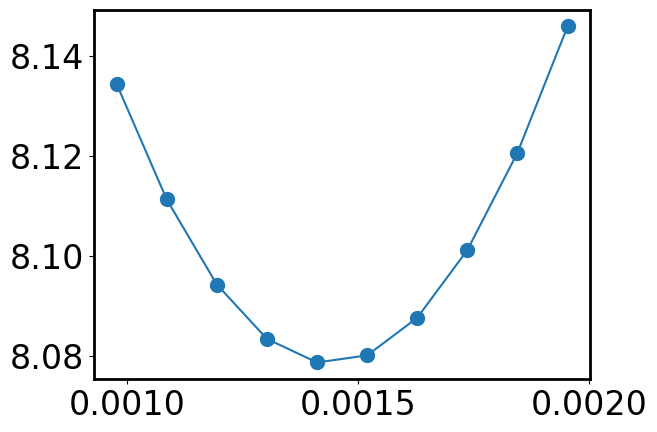

In [930]:
plt.plot(alpha_water_list, np.mean(phi_alpha_water_error_list, axis = 1), '-o')

In [931]:
np.argmin(np.mean(phi_alpha_water_error_list, axis = 1))

4

In [932]:
np.linspace(0.5, 1, 10)[4]

0.7222222222222222

In [934]:
alpha_water = 0.7222222222222222/(64*8)

In [935]:
alpha_Ne = (1-alpha_water*64*8)/(24*8)

In [936]:
alpha_water

0.0014105902777777778

In [937]:
alpha_Ne

0.0014467592592592594

In [98]:
xyz_list_wannier = np.load('xyz_list_20frame_pure_water.npy')

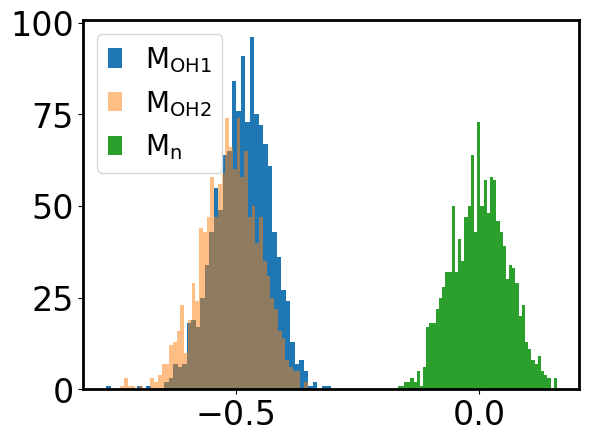

In [108]:
plt.hist(xyz_list_wannier[:, 0].flatten(), bins = 50, label = r'M$_{\mathrm{OH1}}$');
plt.hist(xyz_list_wannier[:, 1].flatten(), bins = 50, label = r'M$_{\mathrm{OH2}}$', alpha = 0.5);
plt.hist(xyz_list_wannier[:, 2].flatten(), bins = 50, label = r'M$_{\mathrm{n}}$');
plt.legend();

In [99]:
np.shape(xyz_list_wannier)

(1280, 3)

In [218]:
step_index_list = np.arange(0, 1200, 60)

In [219]:
xyz_predict_frame_list = []
for step_index in step_index_list:
    xyz_frame = xyz_predict[:, step_index, :]
    xyz_predict_frame_list.append(xyz_frame)

In [220]:
xyz_predict_frame_list = np.array(xyz_predict_frame_list).reshape(-1, 3)

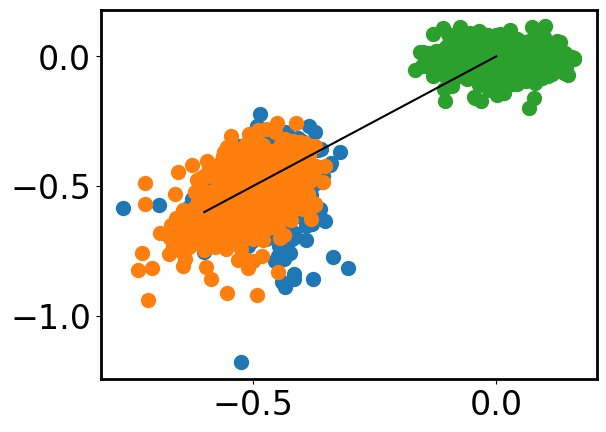

In [221]:
plt.scatter(xyz_list_wannier[:, 0], xyz_predict_frame_list[:, 0])
plt.scatter(xyz_list_wannier[:, 1], xyz_predict_frame_list[:, 1])
plt.scatter(xyz_list_wannier[:, 2], xyz_predict_frame_list[:, 2])

plt.plot([-0.6, 0], [-0.6, 0], color = 'Black')

## contribution of each water molecule to dipole z

In [150]:
wannier_dipole_list = np.load('wannier_dipole_20frame_pure_water.npy')

In [222]:
dipole_alpha = dipole_predict #np.load('dipole_predict_alpha.npy')

In [115]:
np.shape(dipole_alpha)

(76800, 3)

In [223]:
dipole_predict_frame_list = []
for step_index in step_index_list:
    dipole_frame = dipole_alpha[step_index*64:step_index*64+64, :]
    dipole_predict_frame_list.append(dipole_frame)

In [224]:
dipole_predict_frame_list = np.array(dipole_predict_frame_list).reshape(-1,3)

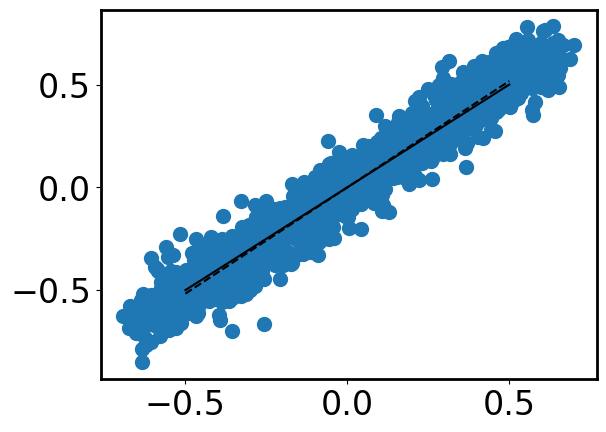

In [225]:
plt.scatter(wannier_dipole_list[:, 2], dipole_predict_frame_list[:, 2])
slope, _ = np.polyfit(wannier_dipole_list[:, 2], dipole_predict_frame_list[:, 2], 1)
plt.plot([-0.5, 0.5], [-0.5, 0.5], color = 'Black')
plt.plot([-0.5, 0.5], [-0.5*slope, 0.5*slope], '--', color = 'Black')


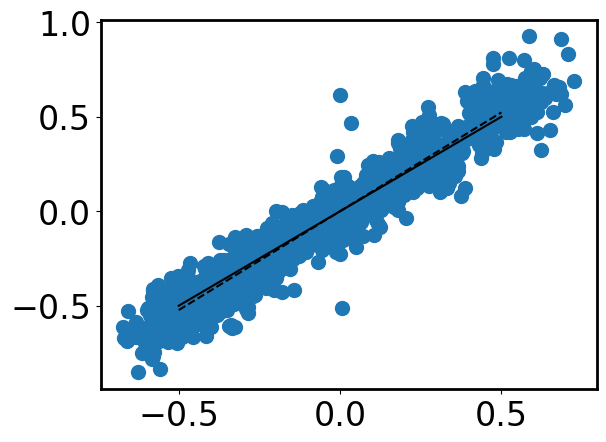

In [226]:
plt.scatter(wannier_dipole_list[:, 1], dipole_predict_frame_list[:, 1])
slope, _ = np.polyfit(wannier_dipole_list[:, 1], dipole_predict_frame_list[:, 1], 1)
plt.plot([-0.5, 0.5], [-0.5, 0.5],color = 'Black')
plt.plot([-0.5, 0.5], [-0.5*slope, 0.5*slope], '--', color = 'Black')


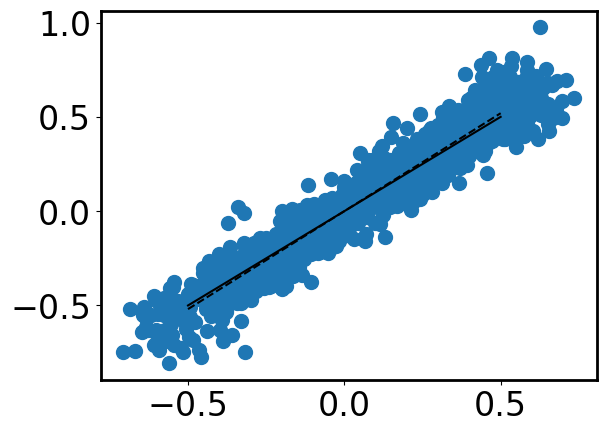

In [227]:
plt.scatter(wannier_dipole_list[:, 0], dipole_predict_frame_list[:, 0])
slope, _ = np.polyfit(wannier_dipole_list[:, 0], dipole_predict_frame_list[:, 0], 1)
plt.plot([-0.5, 0.5], [-0.5, 0.5],color = 'Black')
plt.plot([-0.5, 0.5], [-0.5*slope, 0.5*slope], '--', color = 'Black')


In [136]:
alpha*1/slope

2.365549669641159

In [233]:
d_matrix_x = np.load('d_matrix_x_nfunc100.npy')
d_matrix_y = np.load('d_matrix_y_nfunc100.npy')
d_matrix_z = np.load('d_matrix_z_nfunc100.npy')

In [234]:
x_predict =  mat @ d_matrix_x 
y_predict =  mat @ d_matrix_y
z_predict =  mat @ d_matrix_z 


In [264]:
x_predict_constant = np.zeros_like(x_predict)-0.48539748539344496
y_predict_constant = np.zeros_like(y_predict)-0.5115705943985465
z_predict_constant = np.zeros_like(z_predict)

In [265]:

xyz_predict = np.array([x_predict_constant, y_predict_constant, z_predict_constant]).T

In [266]:
dipole_predict = np.einsum('ij,ijk->ik', xyz_predict, vec_3d_list) 

In [267]:
dipole_frame_z = dipole_predict[:, 2].reshape(-1, 64).sum(axis = 1)


In [249]:
step_index_list = np.arange(0, 1200, 60)
wannier_dipole_list = np.load('wannier_dipole_20frame_pure_water.npy')

In [250]:
dipole_frame_wannier_z = wannier_dipole_list[:, 2].reshape(-1, 64).sum(axis = 1)


In [252]:
slope, _ = np.polyfit(phi_train[step_index_list], dipole_frame_wannier_z, 1)

In [253]:
slope

1.351425041736377

In [263]:
slope

2.0746946521008436

Text(0, 0.5, 'predicted dipole')

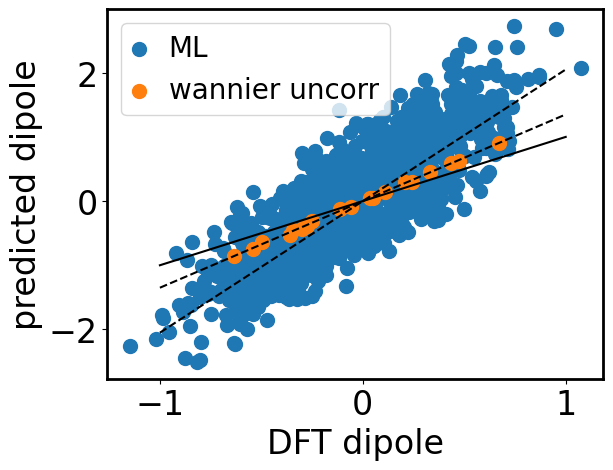

In [268]:
plt.scatter(phi_train, dipole_frame_z, label = 'ML')
plt.scatter(phi_train[step_index_list], dipole_frame_wannier_z, label = 'wannier uncorr')
slope, _ = np.polyfit(phi_train, dipole_frame_z, 1)
plt.plot([-1, 1], [-1, 1], color = 'Black')
plt.plot([-1, 1], [-1*slope, 1*slope], '--', color = 'Black')
plt.plot([-1, 1], [-1*1.35, 1*1.35], '--', color = 'Black')
plt.legend()
plt.xlabel('DFT dipole')
plt.ylabel('predicted dipole')

In [269]:
slope

2.0504537324819365

In [41]:
alpha = 1.3584391176845099

In [42]:
dipole_original = np.load('dipole_predict_original.npy')
dipole_alpha = np.load('dipole_predict_alpha.npy')

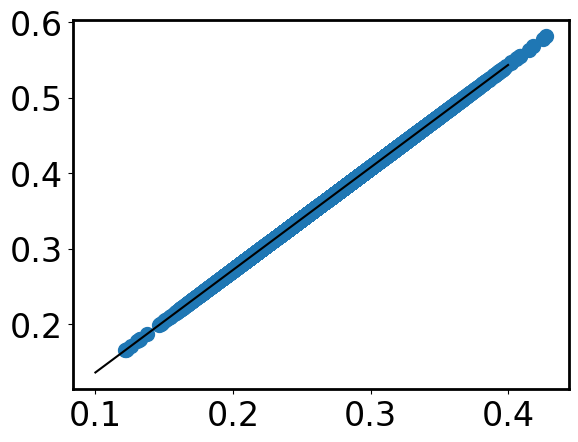

In [47]:
plt.scatter(np.linalg.norm(dipole_original, axis = 1), np.linalg.norm(dipole_alpha, axis = 1))
plt.plot([0.1, 0.4], [0.1*alpha, 0.4*alpha], color = 'Black')

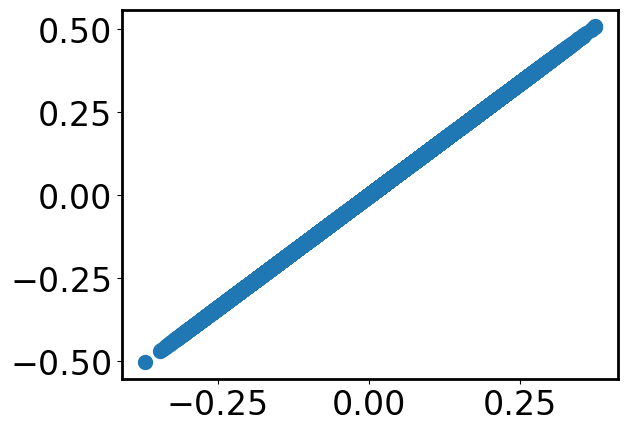

In [49]:
plt.scatter(dipole_original[:, 0], dipole_alpha[:, 0])
#plt.plot([0.1, 0.4], [0.1*alpha, 0.4*alpha], color = 'Black')

In [ ]:
mean: 0.35

In [43]:
np.shape(dipole_original)

(76800, 3)

In [50]:
0.26*alpha

0.3531941705979726

### sklearn ridge regression

In [67]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

In [68]:
scaler = StandardScaler()
A_reshaped = scaler.fit_transform(A.reshape(1200, -1))  # Normalize A

In [77]:
ridge = Ridge(alpha=0.1)  # Regularization strength
ridge.fit(A_reshaped, phi_train)

# Get x and reshape back to (97, 3)
#d_matrix = ridge.coef_.reshape(97, 3)

Ridge(alpha=0.1)

In [78]:
phi_fit = ridge.predict(A_reshaped)

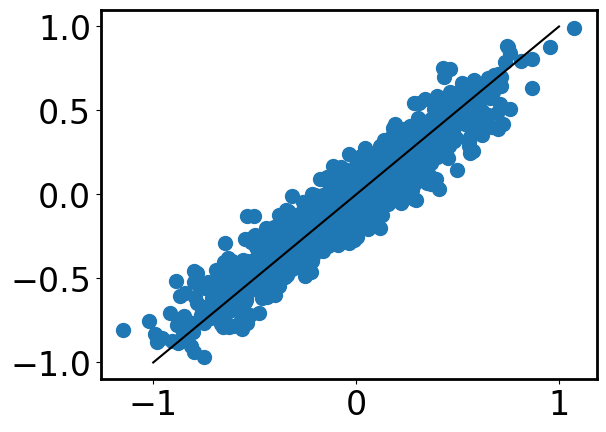

In [79]:
plt.scatter(phi_train, phi_fit)
plt.plot([-1, 1], [-1, 1], color = 'Black')

In [80]:
d_matrix = ridge.coef_.reshape(97, 3)

In [81]:
phi_fit = np.einsum('ijk, jk->i', A, d_matrix)

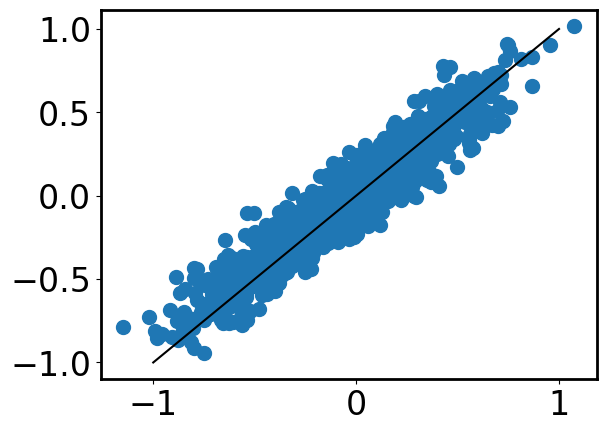

In [82]:
plt.scatter(phi_train, phi_fit)
plt.plot([-1, 1], [-1, 1], color = 'Black')

In [48]:
np.shape(A)

(1200, 97, 3)

In [49]:
m, n, l = A.shape  # Get matrix dimensions
I = np.eye(n)   # Identity matrix of size n x n
lambda_reg = 0.01
# Compute regularized solution: x = (A^T A + lambda*I)^-1 A^T b
mat_inv = np.linalg.inv(A.T @ A + lambda_reg * I) @ A.T

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 97 is different from 1200)

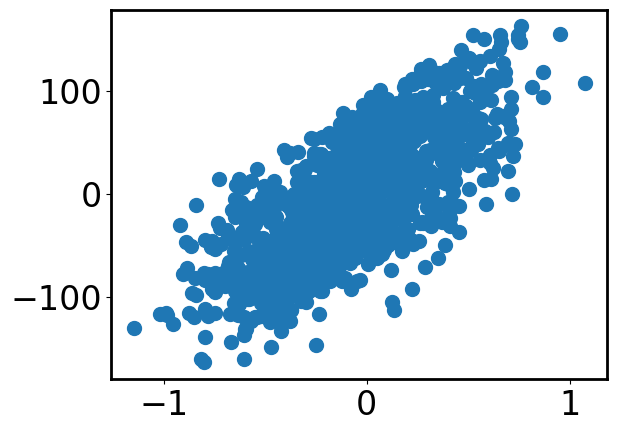

In [35]:
x_predict =  descriptor_list @ d_matrix_x 
y_predict =  descriptor_list @ d_matrix_y
z_predict =  descriptor_list @ d_matrix_z 
#plt.plot(xyz_list[:, 0], x_predict)

In [37]:
xyz_predict = np.array([x_predict, y_predict, z_predict]).T

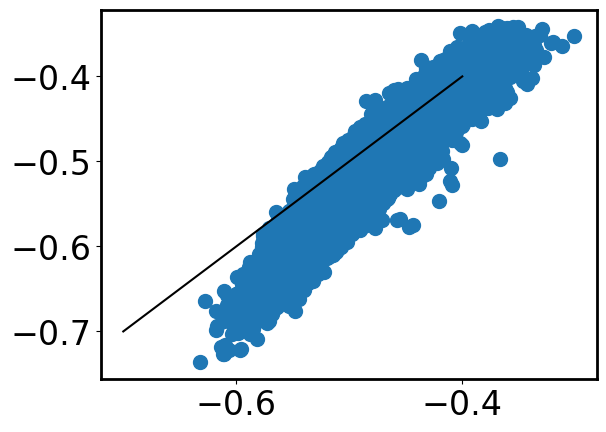

In [62]:
plt.scatter(x_predict, y_predict)
plt.plot([-0.7, -0.4], [-0.7, -0.4], color = 'Black')

In [101]:
np.shape(x_predict)

(76800,)

In [102]:
np.shape(vec_OH1_list)

(76800, 3)

In [104]:
contribution_OH1 = vec_OH1_list * x_predict[:, np.newaxis]
contribution_OH2 = vec_OH2_list * y_predict[:, np.newaxis]
contribution_norm = vec_norm_list * z_predict[:, np.newaxis]

In [105]:
total_contribution = contribution_OH1 + contribution_OH2 + contribution_norm 

In [38]:
dipole_predict = np.einsum('ij,ijk->ik', xyz_predict, vec_3d_list) 

In [45]:
dipole_frame_predict = dipole_predict[:, 2].reshape(-1, 64).sum(axis=1)

Text(0, 0.5, 'predict')

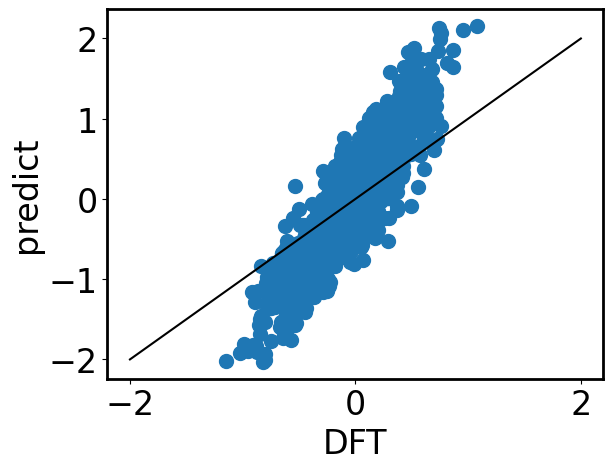

In [48]:
plt.scatter(phi_train, dipole_frame_predict)
plt.plot([-2, 2], [-2, 2], color = 'Black')
plt.xlabel('DFT')
plt.ylabel('predict')

In [132]:
np.mean(xyz_predict[:, 0])

-0.48058428421795707

In [133]:
np.mean(xyz_predict[:, 1])

-0.5087047350362561

In [50]:
dipole_z_from_OH1_predict = vec_3d_list[:, 0] * xyz_predict[:, 0, np.newaxis]
dipole_z_from_OH2_predict = vec_3d_list[:, 1] * xyz_predict[:, 1, np.newaxis]
dipole_z_from_norm_predict = vec_3d_list[:, 2] * xyz_predict[:, 2, np.newaxis] 

In [51]:
np.shape(dipole_z_from_norm_predict)

(76800, 3)

In [54]:
dipole_norm_frame_predict = dipole_z_from_norm_predict[:, 2].reshape(-1, 64).sum(axis=1)
dipole_OH1_frame_predict = dipole_z_from_OH1_predict[:, 2].reshape(-1, 64).sum(axis=1)
dipole_OH2_frame_predict = dipole_z_from_OH2_predict[:, 2].reshape(-1, 64).sum(axis=1)

Text(0, 0.5, 'z contribution OH2')

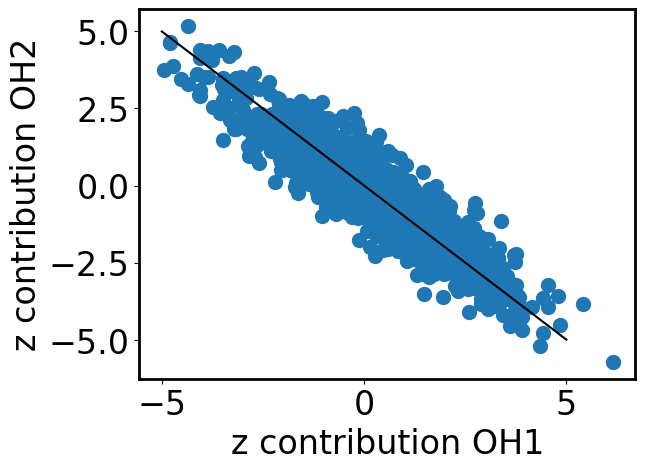

In [108]:
plt.scatter(dipole_OH1_frame_predict, dipole_OH2_frame_predict)
plt.plot([-5, 5], [5, -5], color = 'Black')
plt.xlabel('z contribution OH1')
plt.ylabel('z contribution OH2')

Text(0, 0.5, 'predict')

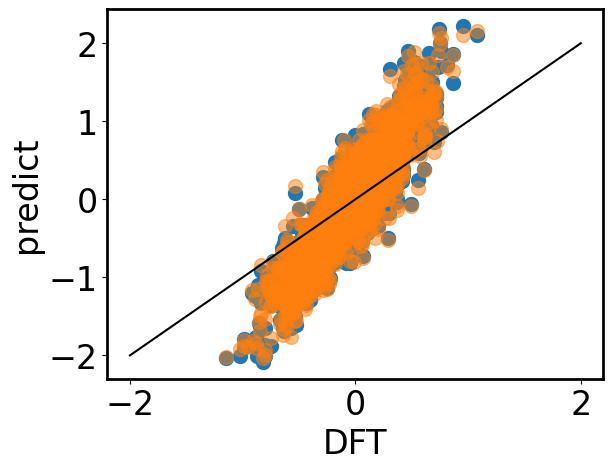

In [120]:
plt.scatter(phi_train, dipole_OH1_frame_predict + dipole_OH2_frame_predict)
plt.scatter(phi_train, dipole_frame_predict, alpha = 0.5)

plt.plot([-2, 2], [-2, 2], color = 'Black')
plt.xlabel('DFT')
plt.ylabel('predict')

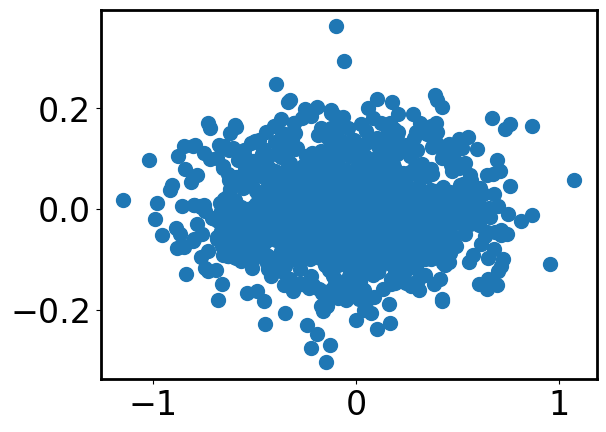

In [53]:
plt.scatter(phi_train, dipole_norm_frame_predict)

In [64]:
np.shape(vec_3d_list)

(76800, 3, 3)

In [75]:
np.linalg.norm(vec_3d_list[0, 1])

0.9999999999999999

In [74]:
np.linalg.norm(vec_3d_list[0, 2])

0.9999999999999999

In [126]:
theta_x = np.arccos(vec_3d_list[:, 2, 0])/np.pi*180
theta_y = np.arccos(vec_3d_list[:, 2, 1])/np.pi*180
theta_z = np.arccos(vec_3d_list[:, 2, 2])/np.pi*180

Text(0.5, 0, '$\\theta$')

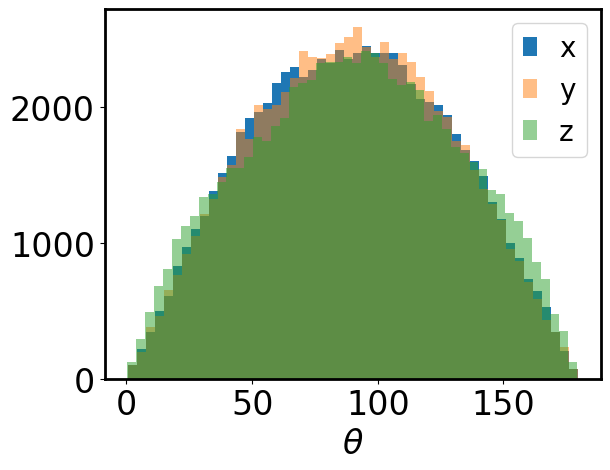

In [130]:
plt.hist(theta_x, bins = 50, label = 'x');
plt.hist(theta_y, bins = 50, alpha = 0.5, label = 'y');
plt.hist(theta_z, bins = 50, alpha = 0.5, label = 'z');
plt.legend()
plt.xlabel(r'$\theta$')

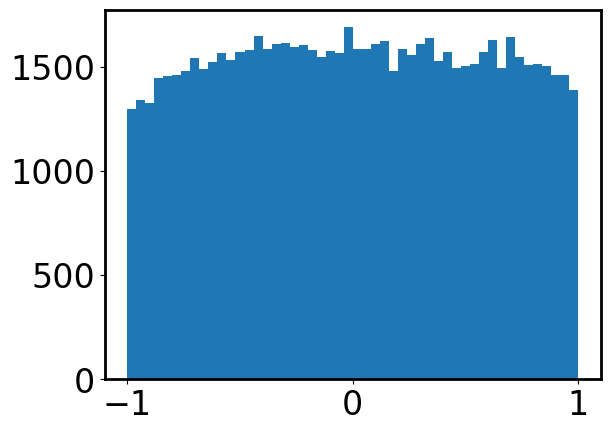

In [80]:
plt.hist(vec_3d_list[:, 2, 1], bins = 50);

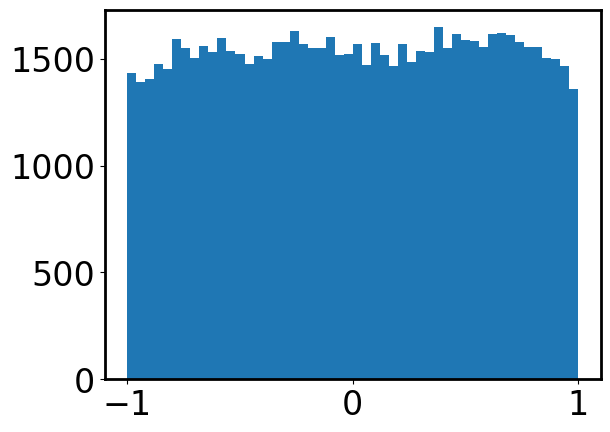

In [79]:
plt.hist(vec_3d_list[:, 2, 0], bins = 50);

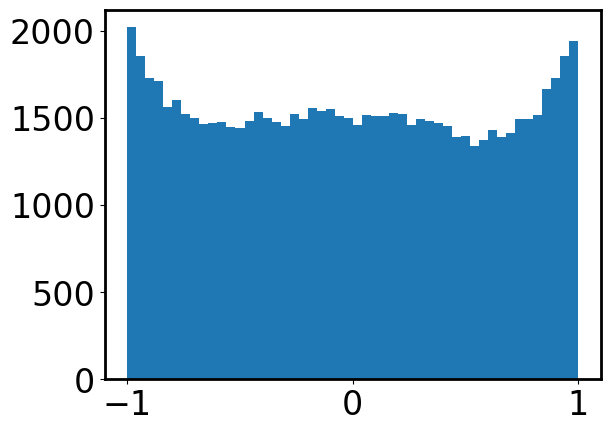

In [78]:
plt.hist(vec_3d_list[:, 2, 2], bins = 50);

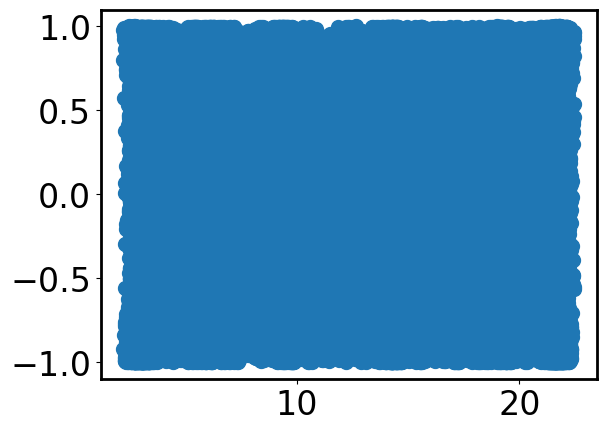

In [86]:
plt.scatter(z_list[:, 0], vec_3d_list[:, 2, 2])

In [87]:
np.min(z_list[:, 0])

2.1942367471884

In [95]:
z_O = z_list[:, 0]
index_l = z_O < 5
index_r = z_O > 20
index_m = np.where((z_O >= 10) & (z_O <= 15))[0]
cos_z = vec_3d_list[:, 2, 2]

In [114]:
theta_z = np.arccos(cos_z)/(np.pi)*180

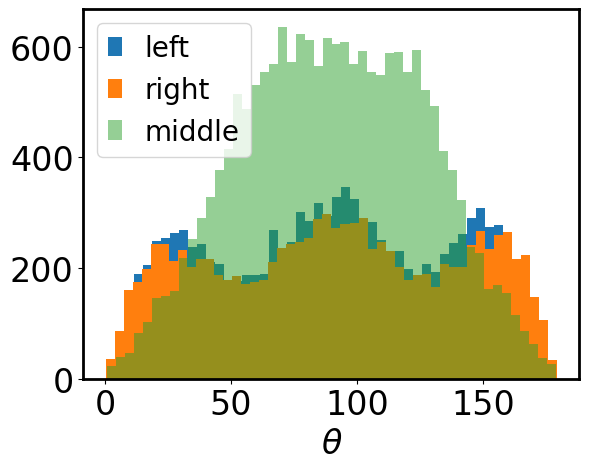

In [116]:
plt.hist(theta_z[index_l], bins = 50, label = 'left');
plt.hist(theta_z[index_r], bins = 50, label = 'right');
plt.hist(theta_z[index_m], bins = 50, alpha = 0.5, label = 'middle');
plt.xlabel(r'$\theta$')
plt.legend()

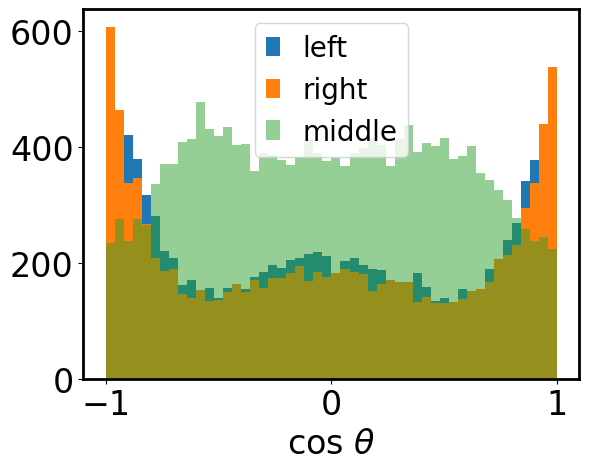

In [117]:
plt.hist(cos_z[index_l], bins = 50, label = 'left');
plt.hist(cos_z[index_r], bins = 50, label = 'right');
plt.hist(cos_z[index_m], bins = 50, alpha = 0.5, label = 'middle');
plt.xlabel(r'cos $\theta$')
plt.legend()

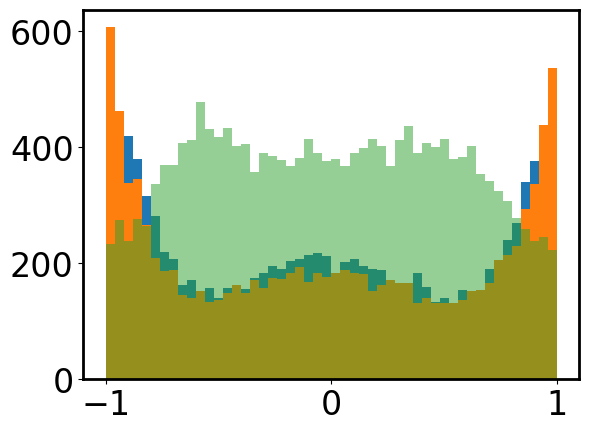

In [100]:
plt.hist(vec_norm_list[index_l, 2], bins = 50);
plt.hist(vec_norm_list[index_r, 2], bins = 50);
plt.hist(vec_norm_list[index_m, 2], bins = 50, alpha = 0.5);


In [131]:
# rOH1 = 0.5
# rOH2 = 0.5
# rnorm = 0

np.shape(vec_3d_list)

(76800, 3, 3)

In [182]:
magnitude_OH1 = -0.5
magnitude_OH2 = -0.5
dipole_fix = vec_3d_list[:,0,:]*magnitude_OH1 +vec_3d_list[:,1,:]*magnitude_OH2
dipole_frame_fix = dipole_fix[:, 2].reshape(-1, 64).sum(axis=1)



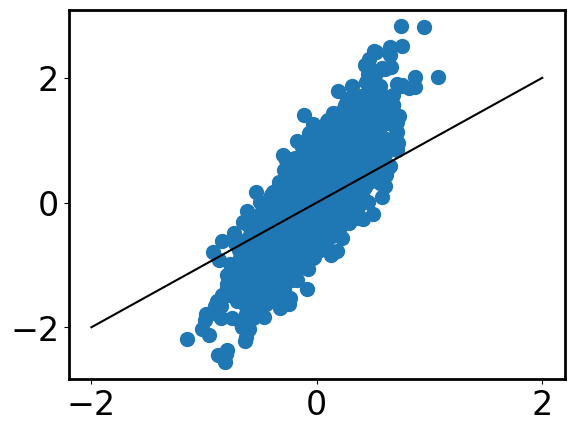

In [186]:
plt.scatter(phi_train, dipole_frame_fix)
#plt.scatter(phi_train, dipole_frame_fix_plusnorm)
plt.plot([-2, 2],[-2,2], color = 'Black')

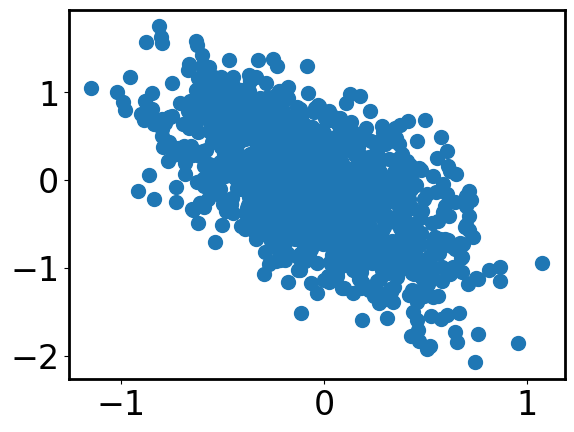

In [189]:
plt.scatter(phi_train,phi_train-dipole_frame_fix)

In [185]:
dipole_fix_norm = vec_3d_list[:,2,:] 
dipole_frame_fix_norm = dipole_fix_norm[:, 2].reshape(-1, 64).sum(axis=1)

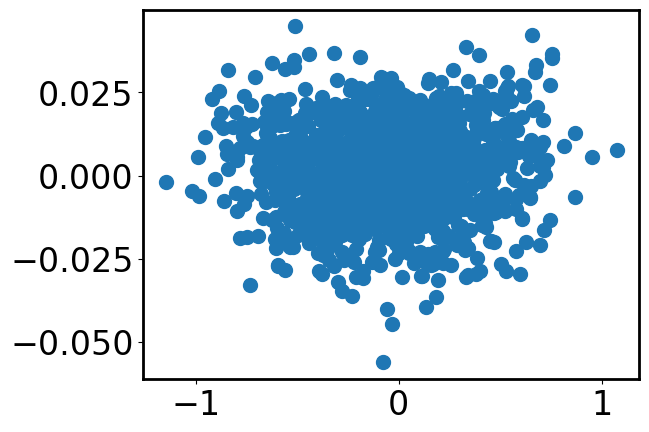

In [188]:
plt.scatter(phi_train, -0.003*dipole_frame_fix_norm)

In [84]:
np.shape(z_list)

(76800, 3)

In [85]:
np.shape(vec_3d_list[:, 2, 2])

(76800,)